<a href="https://colab.research.google.com/github/apester/PINN_KAN_PIKAN/blob/main/PINN_KAN_PIKANV5_PhysicsOnly_v1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KAN, PINN & PIKAN — 2D Advection-Diffusion PDE (Second Spatial Dimension)

$$\\frac{\\partial u}{\\partial t} + c_x \\frac{\\partial u}{\\partial x} + c_y \\frac{\\partial u}{\\partial y} = D\\left(\\frac{\\partial^2 u}{\\partial x^2} + \\frac{\\partial^2 u}{\\partial y^2}\\right)$$

**Domain:** $x, y \\in [0, L]$, $t \\in [0, T]$  
**IC:** $u(x, y, 0) = \\sin\\!\\left(\\dfrac{2\\pi}{L^2}\\, x y\\right)$  
**BC:** Dirichlet $= 0$ on all boundaries  
**Focus:** Second spatial dimension ($y$-direction)

In [1]:
import torch
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA device: Tesla T4


## 0. Imports & Shared Setup

In [2]:
import os, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
if device.type != 'cuda':
    raise RuntimeError(
        'GPU not detected! In Kaggle: Settings > Accelerator > GPU P100, '
        'then Session > Restart & Run All.'
    )

# Works on both Kaggle (/kaggle/working) and Colab (/content)
if os.path.isdir('/kaggle/working'):
    OUT_DIR  = '/kaggle/working/combined_outputs'
    CKPT_DIR = '/kaggle/working/checkpoints'
else:
    OUT_DIR  = '/content/combined_outputs'
    CKPT_DIR = '/content/checkpoints'
os.makedirs(OUT_DIR,  exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print('Output dir     :', OUT_DIR)
print('Checkpoint dir :', CKPT_DIR)

# ── Checkpoint helpers ────────────────────────────────────────────────────────
def ckpt_path(name): return os.path.join(CKPT_DIR, f'{name}.pt')

def save_ckpt(name, payload):
    torch.save(payload, ckpt_path(name))
    print(f'  [ckpt] saved  -> {name}.pt')

def load_ckpt(name):
    p = ckpt_path(name)
    if os.path.exists(p):
        data = torch.load(p, map_location='cpu', weights_only=False)
        print(f'  [ckpt] loaded <- {name}.pt')
        return data
    return None

def save_and_show(filename):
    fpath = os.path.join(OUT_DIR, filename)
    plt.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'  -> saved {filename}')


Device: cuda
Output dir     : /content/combined_outputs
Checkpoint dir : /content/checkpoints


## 1. Shared PDE Parameters

In [3]:
L      = 2.0
CX     = 1.0
CY     = 1.0
D      = 0.5
T      = 1.0
BC_VAL = 0.0

Nx = 80
Ny = 80
DX = L / Nx
DY = L / Ny
DT = 2e-3
Nt = int(T / DT)

x_grid = np.linspace(0.0, L, Nx + 1)
y_grid = np.linspace(0.0, L, Ny + 1)

def ic_xy(x, y):
    return np.sin(2.0 * np.pi / L**2 * x * y)

def normalise_inputs(x, y, t):
    xn = 2.0 * x / L - 1.0
    yn = 2.0 * y / L - 1.0
    tn = 2.0 * t / T - 1.0
    return xn, yn, tn

print('=' * 65)
print('  Shared PDE Parameters')
print('=' * 65)
print(f'  Domain  : x,y in [0, {L}],  t in [0, {T}]')
print(f'  Grid    : Nx={Nx}, Ny={Ny}, Nt={Nt}')
print(f'  Dx={DX:.4f}  Dy={DY:.4f}  Dt={DT}')
print(f'  cx={CX},  cy={CY},  D={D}')
print(f'  IC: u(x,y,0) = sin(2*pi/L^2 * x*y)')
print(f'  BC: u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Input normalisation: x,y,t -> [-1, 1]  (all models)')
print('=' * 65)

  Shared PDE Parameters
  Domain  : x,y in [0, 2.0],  t in [0, 1.0]
  Grid    : Nx=80, Ny=80, Nt=500
  Dx=0.0250  Dy=0.0250  Dt=0.002
  cx=1.0,  cy=1.0,  D=0.5
  IC: u(x,y,0) = sin(2*pi/L^2 * x*y)
  BC: u = 0.0 on all boundaries (Dirichlet)
  Input normalisation: x,y,t -> [-1, 1]  (all models)


## 2. Ground Truth — ADI Crank–Nicolson Solver

In [4]:
def thomas(a, b, c, d):
    n = len(b)
    cp = np.zeros(n - 1)
    dp = np.zeros(n)
    cp[0] = c[0] / b[0]
    dp[0] = d[0] / b[0]
    for i in range(1, n - 1):
        denom = b[i] - a[i - 1] * cp[i - 1]
        cp[i] = c[i] / denom
        dp[i] = (d[i] - a[i - 1] * dp[i - 1]) / denom
    denom = b[-1] - a[-1] * cp[-1]
    dp[-1] = (d[-1] - a[-1] * dp[-2]) / denom
    sol = np.zeros(n)
    sol[-1] = dp[-1]
    for i in reversed(range(n - 1)):
        sol[i] = dp[i] - cp[i] * sol[i + 1]
    return sol


def solve_2d_adi():
    x = x_grid
    y = y_grid
    t = np.linspace(0, T, Nt + 1)

    C = np.zeros((Nt + 1, Ny + 1, Nx + 1))
    X, Y = np.meshgrid(x, y, indexing='xy')
    C[0] = ic_xy(X, Y)
    C[0, 0, :] = C[0, -1, :] = C[0, :, 0] = C[0, :, -1] = BC_VAL

    rx = D * DT / (2 * DX * DX)
    ry = D * DT / (2 * DY * DY)

    ax_d = -rx * np.ones(Nx - 2)
    bx_d = (1 + 2 * rx) * np.ones(Nx - 1)
    cx_d = -rx * np.ones(Nx - 2)

    ay_d = -ry * np.ones(Ny - 2)
    by_d = (1 + 2 * ry) * np.ones(Ny - 1)
    cy_d = -ry * np.ones(Ny - 2)

    for n in range(Nt):
        U = C[n].copy()

        A = np.zeros_like(U)
        A[:, 1:-1] += CX * (U[:, 1:-1] - U[:, :-2]) / DX
        A[1:-1, :] += CY * (U[1:-1, :] - U[:-2, :]) / DY

        Lap = np.zeros_like(U)
        Lap[1:-1, 1:-1] = (
            (U[1:-1, 2:] - 2 * U[1:-1, 1:-1] + U[1:-1, :-2]) / (DX * DX)
            + (U[2:, 1:-1] - 2 * U[1:-1, 1:-1] + U[:-2, 1:-1]) / (DY * DY)
        )

        RHS = U - DT * A + (D * DT / 2) * Lap

        Ustar = U.copy()
        for j in range(1, Ny):
            Ustar[j, 1:-1] = thomas(ax_d, bx_d, cx_d, RHS[j, 1:-1])
        Ustar[0, :] = Ustar[-1, :] = Ustar[:, 0] = Ustar[:, -1] = BC_VAL

        Un = Ustar.copy()
        for i in range(1, Nx):
            Un[1:-1, i] = thomas(ay_d, by_d, cy_d, Ustar[1:-1, i])
        Un[0, :] = Un[-1, :] = Un[:, 0] = Un[:, -1] = BC_VAL

        C[n + 1] = Un

    return x, y, t, C


print('Solving ground truth (ADI-Crank-Nicolson) ...', flush=True)
t0_gt = time.time()
x_sol, y_sol, t_sol, C_gt = solve_2d_adi()
print(f'  Done in {time.time() - t0_gt:.2f}s  |  shape: {C_gt.shape}')

Solving ground truth (ADI-Crank-Nicolson) ...
  Done in 9.84s  |  shape: (501, 81, 81)


## 3. KAN Model Definition

In [6]:
class VKANLayer(nn.Module):
    def __init__(self, in_dim, out_dim, grid_size=5, spline_order=3,
                 grid_lo=-1.0, grid_hi=1.0):
        super().__init__()
        self.in_dim  = in_dim
        self.out_dim = out_dim
        self.k       = spline_order
        n_basis      = grid_size + spline_order

        self.coeff = nn.Parameter(torch.zeros(in_dim, out_dim, n_basis))
        nn.init.normal_(self.coeff, std=0.1)
        self.res_w = nn.Parameter(torch.zeros(in_dim, out_dim))

        h     = (grid_hi - grid_lo) / grid_size
        knots = torch.linspace(
            grid_lo - spline_order * h,
            grid_hi + spline_order * h,
            grid_size + 2 * spline_order + 1
        )
        self.register_buffer('knots', knots)

    def _basis(self, x):
        # Hard indicator basis: B-spline degree-0 uses step functions.
        # Has zero or undefined second derivatives — suitable for supervised
        # regression (KAN) but not for PDE residuals requiring autograd.
        k  = self.k
        t  = self.knots
        n  = len(t) - k - 1
        xv = x.unsqueeze(-1)
        tv = t.view(1, 1, -1)
        B  = ((xv >= tv[:, :, :-1]) & (xv < tv[:, :, 1:])).float()
        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] +                   ((tR2 - xv) / dR) * B[:, :, 1:]
        return B[:, :, :n]

    def forward(self, x):
        B      = self._basis(x)
        spline = torch.einsum('bin,ion->bio', B, self.coeff)
        res    = torch.einsum('bi,io->bio', F.silu(x), self.res_w)
        return (spline + 0.1 * res).sum(dim=1)


class SmoothVKANLayer(VKANLayer):
    """
    Drop-in replacement for VKANLayer with a smooth sigmoid basis.
    The hard step-function indicator in the standard B-spline degree-0 basis
    has zero or undefined second derivatives everywhere, causing PDE residuals
    computed via torch.autograd.grad(create_graph=True) to explode to ~1e9.
    This subclass replaces the step function with a sigmoid approximation:
        sigmoid((x - t_left) / tau) - sigmoid((x - t_right) / tau)
    which is infinitely differentiable and has bounded second derivatives,
    making it compatible with the second-order autograd required by pde_residual.
    The sharpness parameter tau controls the smoothing: smaller = sharper
    approximation of the original step function.
    """
    # tau=0.2 reduces the peak second derivative of each sigmoid basis
    # function by 4x compared to tau=0.1, keeping PDE gradients bounded.
    SMOOTH_TAU = 0.2

    def _basis(self, x):
        k  = self.k
        t  = self.knots
        n  = len(t) - k - 1
        xv = x.unsqueeze(-1)
        tv = t.view(1, 1, -1)
        tau = self.SMOOTH_TAU
        # Smooth indicator: replaces hard (xv >= tL) & (xv < tR) step function
        B = torch.sigmoid((xv - tv[:, :, :-1]) / tau) *             torch.sigmoid((tv[:, :, 1:] - xv) / tau)
        for r in range(1, k + 1):
            tL  = tv[:, :, :-(r + 1)];  tR  = tv[:, :, r:-1]
            dL  = (tR  - tL ).clamp(min=1e-8)
            tL2 = tv[:, :, 1:-r];       tR2 = tv[:, :, r + 1:]
            dR  = (tR2 - tL2).clamp(min=1e-8)
            B   = ((xv - tL) / dL) * B[:, :, :-1] +                   ((tR2 - xv) / dR) * B[:, :, 1:]
        return B[:, :, :n]


class KAN(nn.Module):
    def __init__(self, widths, grid_size=5, spline_order=3, smooth=False):
        """
        smooth=False (default): uses VKANLayer — standard hard B-spline basis.
        smooth=True: uses SmoothVKANLayer — sigmoid basis safe for second-order autograd.
        """
        super().__init__()
        layer_cls = SmoothVKANLayer if smooth else VKANLayer
        layers, norms = [], []
        for i in range(len(widths) - 1):
            layers.append(layer_cls(widths[i], widths[i+1], grid_size, spline_order))
            if i < len(widths) - 2:
                norms.append(nn.LayerNorm(widths[i+1]))
        self.layers = nn.ModuleList(layers)
        self.norms  = nn.ModuleList(norms)

    def forward(self, x):
        for i, layer in enumerate(self.layers):
            x = layer(x)
            if i < len(self.norms):
                x = self.norms[i](x)
        return x

print('KAN model class defined (VKANLayer + SmoothVKANLayer).')

KAN model class defined (VKANLayer + SmoothVKANLayer).


## 4. Shared Dataset (GT Snapshots)

In [10]:
N_SNAPS    = 100
save_every = max(1, Nt // N_SNAPS)
snap_idx_list = list(range(0, Nt + 1, save_every))
if snap_idx_list[-1] != Nt:
    snap_idx_list.append(Nt)

snap_t = t_sol[snap_idx_list]
snap_U = C_gt[snap_idx_list]

XX, YY = np.meshgrid(x_grid, y_grid, indexing='ij')
snap_U_ij = snap_U.transpose(0, 2, 1)

inp_list, tgt_list = [], []
for k, tk in enumerate(snap_t):
    t_plane = np.full((Nx + 1, Ny + 1), tk, dtype=np.float32)
    inp_list.append(
        np.stack([XX, YY, t_plane], axis=-1).astype(np.float32).reshape(-1, 3)
    )
    tgt_list.append(snap_U_ij[k].astype(np.float32).ravel())

inputs_kan  = np.concatenate(inp_list, axis=0)
targets_kan = np.concatenate(tgt_list, axis=0)

xn_kan, yn_kan, tn_kan = normalise_inputs(
    inputs_kan[:, 0], inputs_kan[:, 1], inputs_kan[:, 2]
)
inputs_kan_n = np.stack([xn_kan, yn_kan, tn_kan], axis=1).astype(np.float32)

N_kan = len(inputs_kan_n)
rng   = np.random.default_rng(42)
idx   = rng.permutation(N_kan)
split = int(0.85 * N_kan)
tr, va = idx[:split], idx[split:]

X_tr = torch.from_numpy(inputs_kan_n[tr])
y_tr = torch.from_numpy(targets_kan[tr]).unsqueeze(1)
X_va = torch.from_numpy(inputs_kan_n[va])
y_va = torch.from_numpy(targets_kan[va]).unsqueeze(1)

BATCH        = 512
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH * 8)

print(f'Dataset: {N_kan:,} samples  |  train {len(tr):,} / val {len(va):,}')
print(f'Snapshots: {len(snap_t)}')

Dataset: 662,661 samples  |  train 563,261 / val 99,400
Snapshots: 101


## 5. KAN — Training

In [11]:
KAN_WIDTHS     = [3, 32, 32, 32, 1]
KAN_GRID_SIZE  = 8
KAN_SPLINE_ORD = 3
KAN_MAX_WALL   = 7200.0
KAN_THRESHOLD  = 1e-6
KAN_PATIENCE   = 50
KAN_MAX_EPOCHS = 5000

kan_model    = KAN(KAN_WIDTHS, KAN_GRID_SIZE, KAN_SPLINE_ORD).to(device)
kan_n_params = sum(p.numel() for p in kan_model.parameters())
print(f'KAN: {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}  params={kan_n_params:,}')

kan_optimizer = torch.optim.AdamW(kan_model.parameters(), lr=3e-3, weight_decay=1e-4)
kan_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    kan_optimizer, mode='min', patience=15, factor=0.5, min_lr=5e-6
)
kan_criterion = nn.MSELoss()

# ── Resume from checkpoint if available ──────────────────────────────────────
_kan_ckpt = load_ckpt('kan')
if _kan_ckpt is not None:
    kan_model.load_state_dict(_kan_ckpt['model_state'])
    kan_model.to(device)
    kan_train_losses = _kan_ckpt['train_losses']
    kan_val_losses   = _kan_ckpt['val_losses']
    kan_lr_history   = _kan_ckpt['lr_history']
    kan_best_val     = _kan_ckpt['best_val']
    kan_best_state   = _kan_ckpt['best_state']
    kan_no_improve   = _kan_ckpt['no_improve']
    kan_stop_reason  = _kan_ckpt['stop_reason']
    kan_prev_val     = _kan_ckpt['prev_val']
    _kan_start_epoch = _kan_ckpt['epoch'] + 1
    kan_wall_start   = time.time()
    print(f'KAN resumed from epoch {_kan_ckpt["epoch"]}  best_val={kan_best_val:.6f}')
else:
    kan_train_losses, kan_val_losses, kan_lr_history = [], [], []
    kan_best_val, kan_best_state = float('inf'), None
    kan_no_improve  = 0
    kan_stop_reason = 'max_epochs'
    kan_prev_val    = float('inf')
    _kan_start_epoch = 1
    kan_wall_start  = time.time()

print(f'\n{"Epoch":>6} | {"Train Loss":>12} | {"Val MSE":>12} | {"LR":>9} | {"Wall":>7}')
print('-' * 60)

for epoch in range(_kan_start_epoch, KAN_MAX_EPOCHS + 1):
    elapsed = time.time() - kan_wall_start
    if elapsed >= KAN_MAX_WALL:
        kan_stop_reason = 'time_limit'; break

    kan_model.train()
    t_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        kan_optimizer.zero_grad()
        loss = kan_criterion(kan_model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(kan_model.parameters(), 1.0)
        kan_optimizer.step()
        t_loss += loss.item() * xb.size(0)
    t_loss /= len(X_tr)

    kan_model.eval()
    v_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            v_loss += kan_criterion(kan_model(xb), yb).item() * xb.size(0)
    v_loss /= len(X_va)

    kan_scheduler.step(v_loss)
    cur_lr = kan_optimizer.param_groups[0]['lr']

    kan_train_losses.append(t_loss)
    kan_val_losses.append(v_loss)
    kan_lr_history.append(cur_lr)

    if v_loss < kan_best_val:
        kan_best_val   = v_loss
        kan_best_state = {k: v.cpu().clone() for k, v in kan_model.state_dict().items()}

    delta = abs(kan_prev_val - v_loss)
    if epoch % 50 == 0 or epoch == 1:
        print(f'{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

    # Save checkpoint every 50 epochs
    if epoch % 50 == 0:
        save_ckpt('kan', {
            'epoch': epoch, 'model_state': {k: v.cpu().clone() for k, v in kan_model.state_dict().items()},
            'train_losses': kan_train_losses, 'val_losses': kan_val_losses,
            'lr_history': kan_lr_history, 'best_val': kan_best_val,
            'best_state': kan_best_state, 'no_improve': kan_no_improve,
            'stop_reason': kan_stop_reason, 'prev_val': v_loss,
        })

    if epoch > 50:
        kan_no_improve = kan_no_improve + 1 if delta < KAN_THRESHOLD else 0
        if kan_no_improve >= KAN_PATIENCE:
            kan_stop_reason = 'convergence'
            print(f'\n  KAN converged at epoch {epoch}! |DLoss|={delta:.2e} < {KAN_THRESHOLD:.0e}')
            break

    kan_prev_val = v_loss

if kan_best_state:
    kan_model.load_state_dict(kan_best_state)
    kan_model.to(device)

kan_total_time  = time.time() - kan_wall_start
kan_final_epoch = len(kan_train_losses)

print('\n' + '=' * 60)
print(f'  KAN Stop reason   : {kan_stop_reason}')
print(f'  KAN Epochs run    : {kan_final_epoch}')
print(f'  KAN Best val MSE  : {kan_best_val:.6f}')
print(f'  KAN Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print('=' * 60)

# Save final KAN checkpoint (marks training as fully complete)
save_ckpt('kan_done', {
    'model_state': kan_best_state, 'train_losses': kan_train_losses,
    'val_losses': kan_val_losses, 'lr_history': kan_lr_history,
    'best_val': kan_best_val, 'stop_reason': kan_stop_reason,
    'final_epoch': kan_final_epoch, 'total_time': kan_total_time,
})

KAN: [3, 32, 32, 32, 1]  grid=8  order=3  params=26,304

 Epoch |   Train Loss |      Val MSE |        LR |    Wall
------------------------------------------------------------
     1 |     0.007283 |     0.000584 |  3.00e-03 |   0.0s
    50 |     0.000002 |     0.000001 |  1.50e-03 | 663.9s
  [ckpt] saved  -> kan.pt
   100 |     0.000000 |     0.000000 |  7.50e-04 | 1337.4s
  [ckpt] saved  -> kan.pt
   150 |     0.000000 |     0.000000 |  1.88e-04 | 2008.9s
  [ckpt] saved  -> kan.pt

  KAN converged at epoch 158! |DLoss|=3.41e-08 < 1e-06

  KAN Stop reason   : convergence
  KAN Epochs run    : 158
  KAN Best val MSE  : 0.000000
  KAN Training time : 2130.0s (35.5 min)
  [ckpt] saved  -> kan_done.pt


## 6. KAN — Predictions & Metrics

In [ ]:
kan_model.eval()
CHUNK = 4096
kan_pred_list = []
X_all_t = torch.from_numpy(inputs_kan_n).to(device)

with torch.no_grad():
    for i in range(0, len(X_all_t), CHUNK):
        kan_pred_list.append(kan_model(X_all_t[i:i+CHUNK]).cpu().numpy().ravel())

kan_pred_all = np.concatenate(kan_pred_list)
kan_true_all = targets_kan

kan_mse_full = float(np.mean((kan_pred_all - kan_true_all)**2))
kan_rmse_all = float(np.sqrt(kan_mse_full))
kan_rel_err  = float(
    np.mean(np.abs(kan_pred_all - kan_true_all)) / (np.mean(np.abs(kan_true_all)) + 1e-12)
)

print(f'KAN Full-dataset MSE  : {kan_mse_full:.6f}')
print(f'KAN RMSE              : {kan_rmse_all:.6f}')
print(f'KAN Relative L1 error : {kan_rel_err*100:.2f} %')

KAN_pred_snaps = kan_pred_all.reshape(len(snap_t), Nx + 1, Ny + 1)
KAN_true_snaps = kan_true_all.reshape(len(snap_t), Nx + 1, Ny + 1)

FS          = 12
snap_idxs_4 = np.linspace(0, len(snap_t) - 1, 4, dtype=int)
ix_mid      = (Nx + 1) // 2
kan_rmse_t  = [np.sqrt(np.mean((KAN_pred_snaps[k] - KAN_true_snaps[k])**2))
               for k in range(len(snap_t))]

KAN Full-dataset MSE  : 0.000000
KAN RMSE              : 0.000149
KAN Relative L1 error : 0.07 %


## 7. KAN — Plots

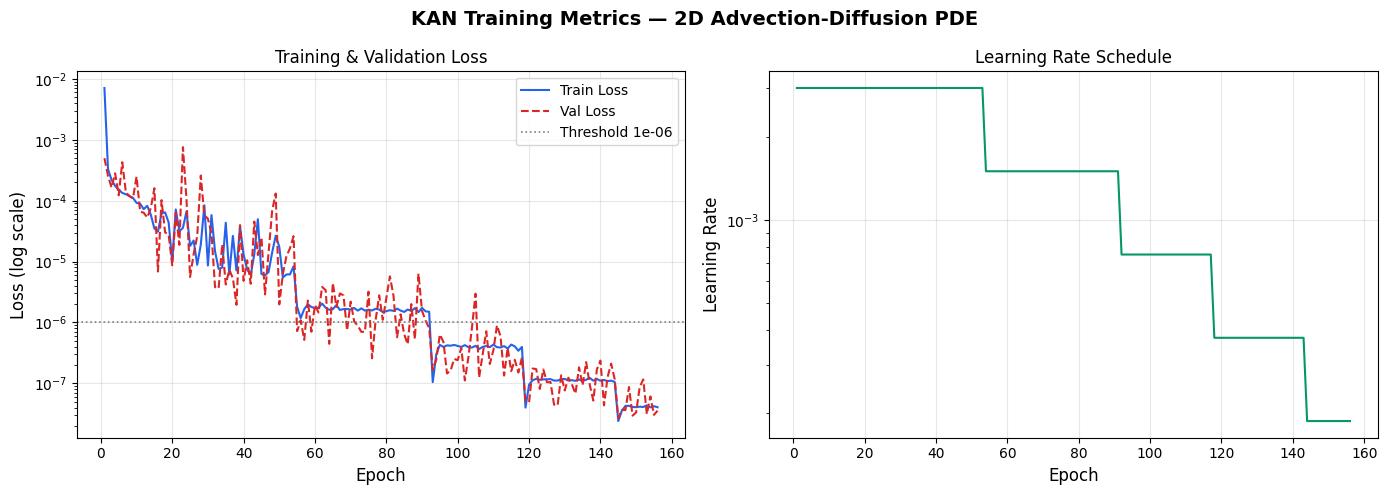

  -> saved KAN_01_training_metrics.png


In [ ]:
ep_a_kan = np.arange(1, kan_final_epoch + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KAN Training Metrics — 2D Advection-Diffusion PDE',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_kan, kan_train_losses, lw=1.5, color='#2563EB', label='Train Loss')
ax.semilogy(ep_a_kan, kan_val_losses,   lw=1.5, color='#DC2626', ls='--', label='Val Loss')
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.2, label=f'Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training & Validation Loss')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(ep_a_kan, kan_lr_history, lw=1.5, color='#059669')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Learning Rate', fontsize=FS)
ax.set_title('Learning Rate Schedule')
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_01_training_metrics.png')


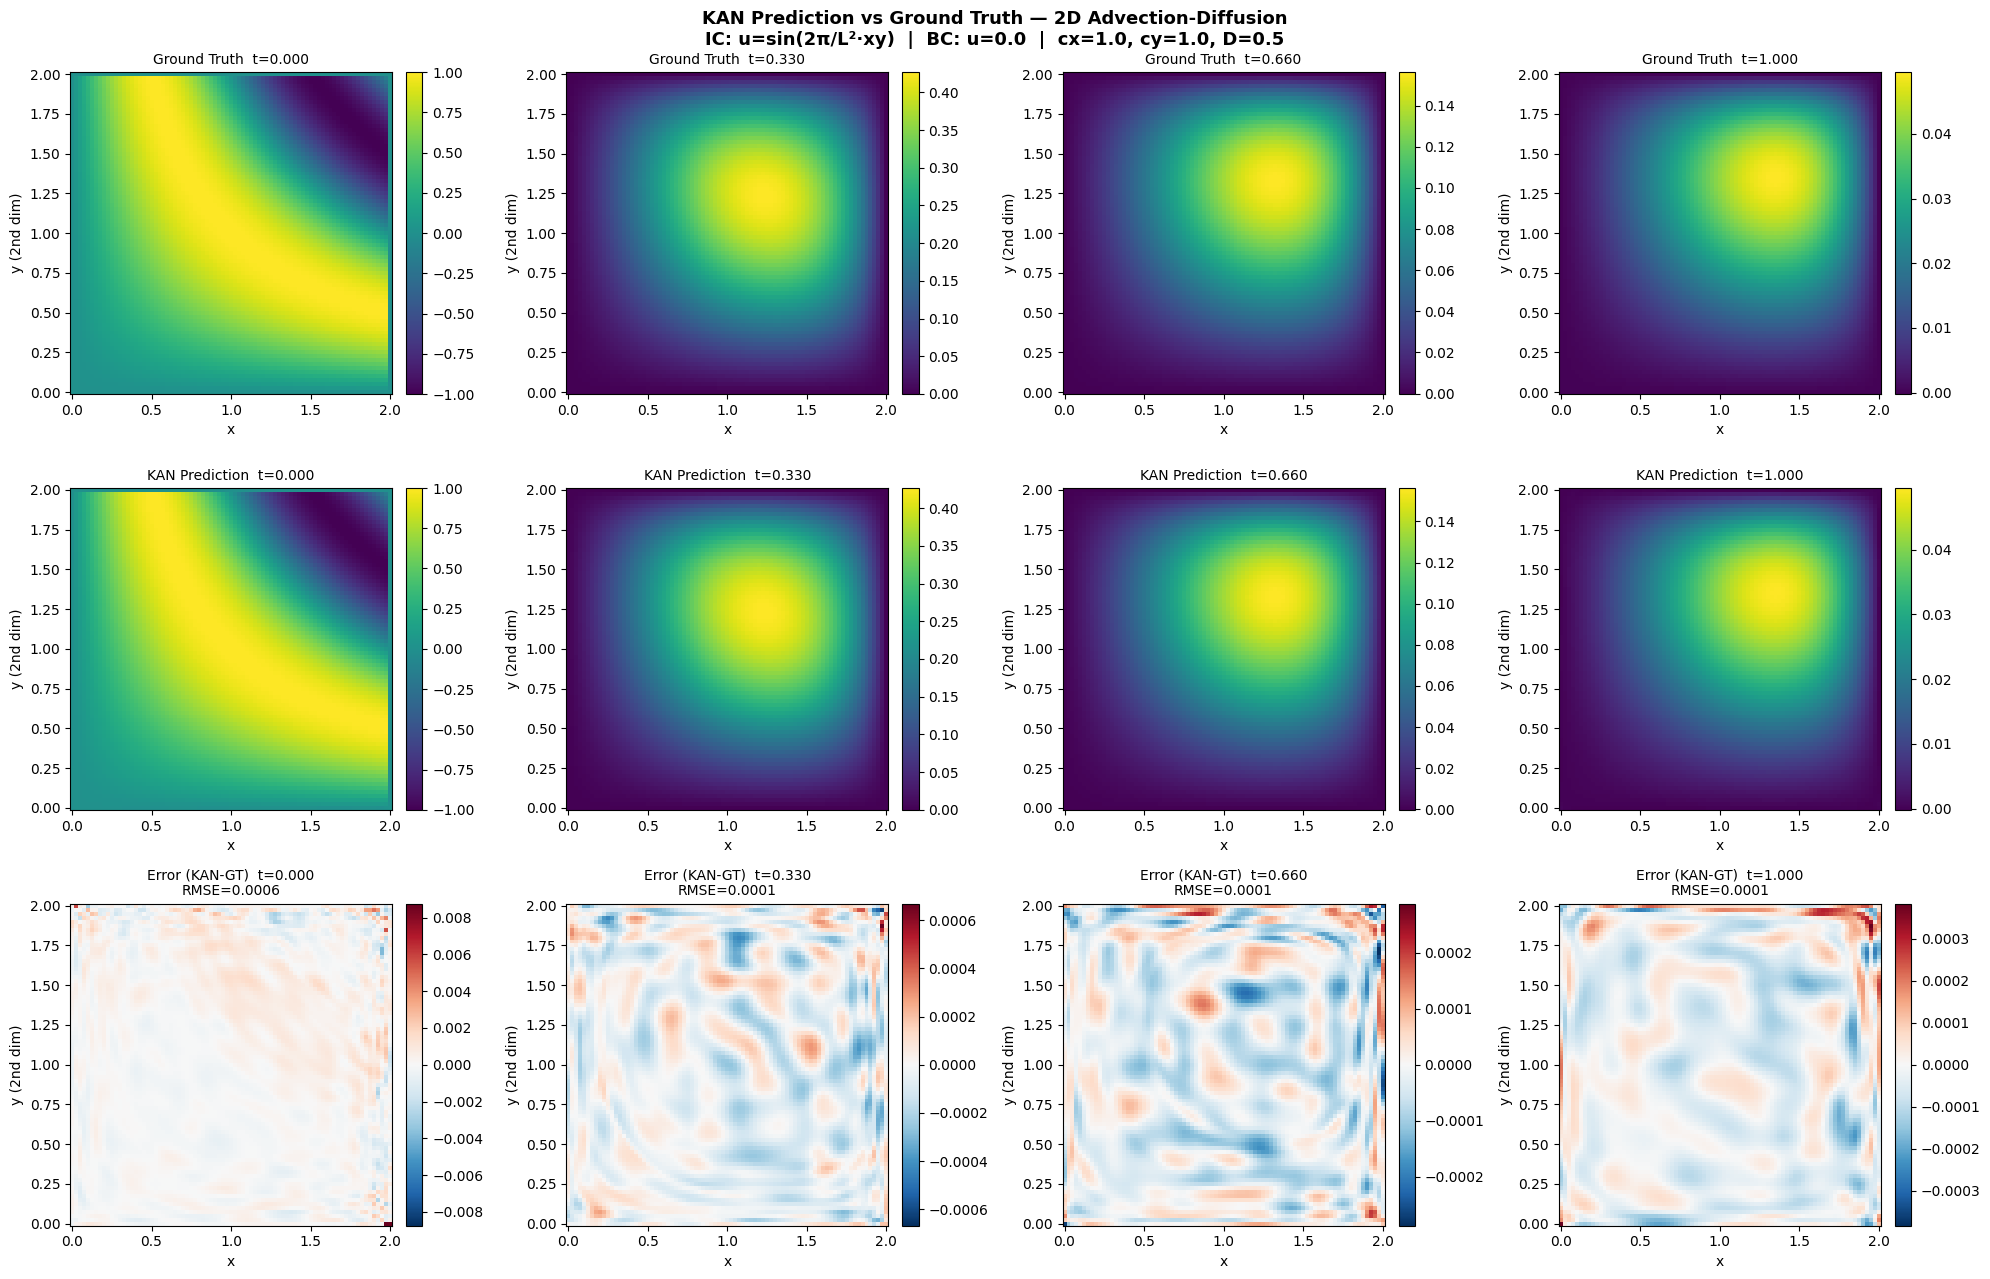

  -> saved KAN_02_snapshot_comparison.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'KAN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=sin(2\u03c0/L\u00b2\u00b7xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk  = snap_t[si]
    Ugt = KAN_true_snaps[si]
    Ukn = KAN_pred_snaps[si]
    err = Ukn - Ugt
    vmin = min(Ugt.min(), Ukn.min()); vmax = max(Ugt.max(), Ukn.max())
    emax = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'KAN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_k = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (KAN-GT)  t={tk:.3f}\nRMSE={rmse_k:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('KAN_02_snapshot_comparison.png')

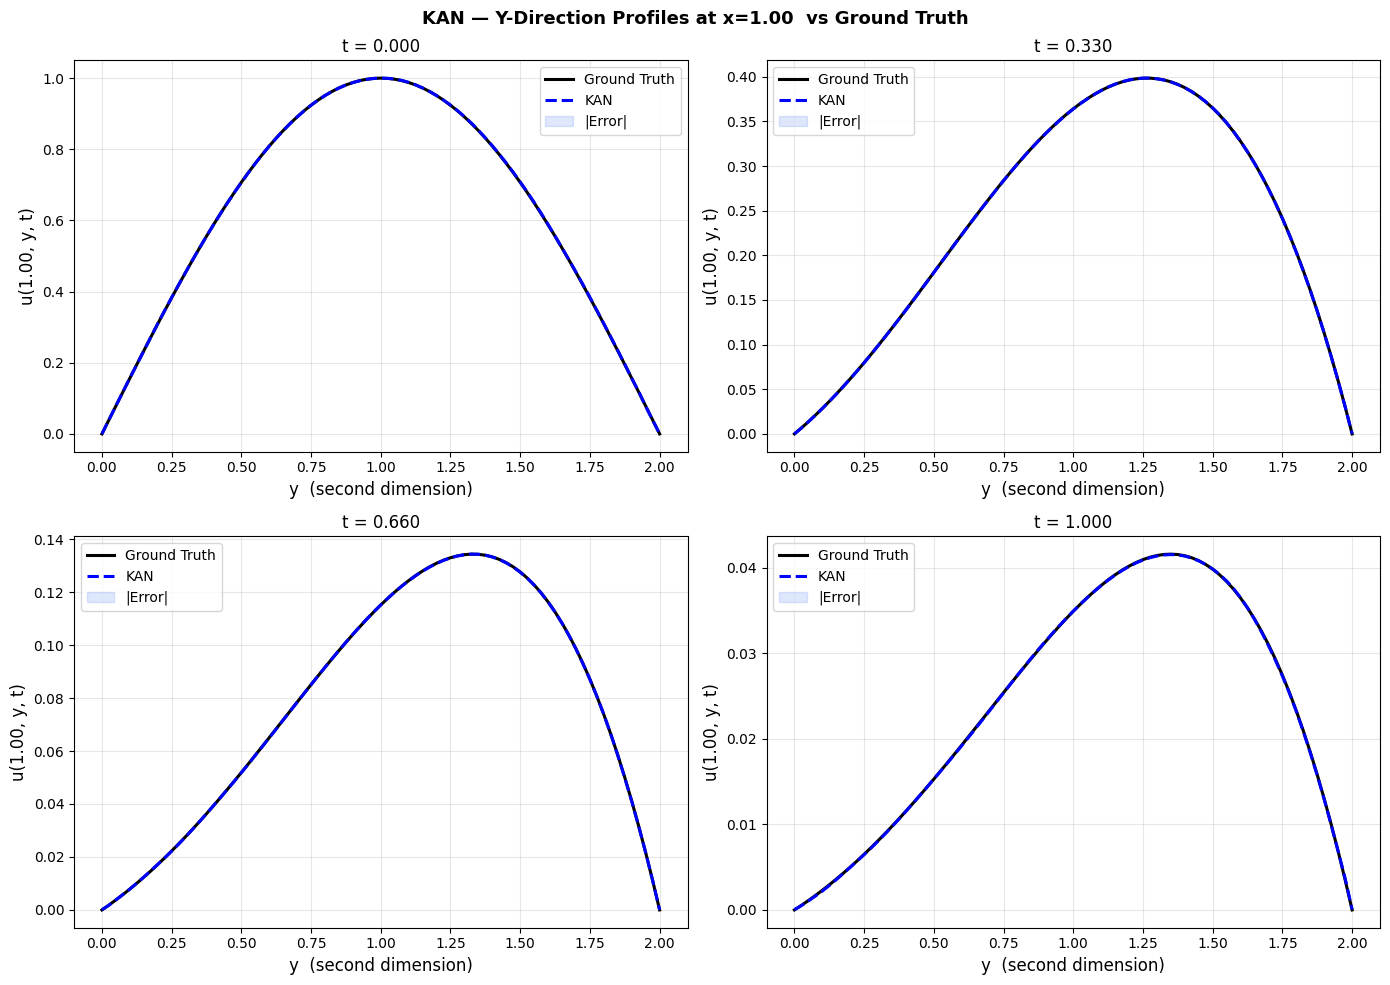

  -> saved KAN_03_y_profiles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'KAN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    kn_y = KAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, kn_y, 'b--', lw=2.2, label='KAN')
    ax.fill_between(y_grid, gt_y, kn_y, alpha=0.15, color='#2563EB', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('KAN_03_y_profiles.png')

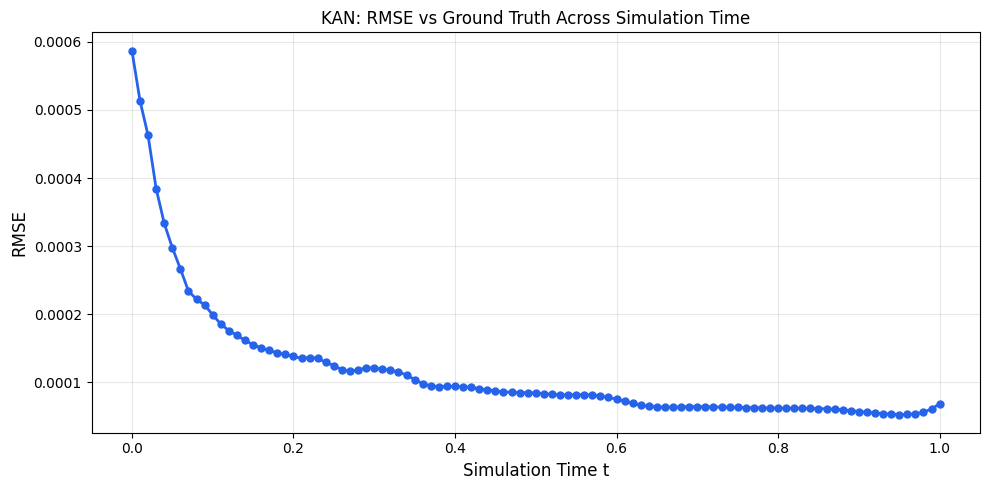

  -> saved KAN_04_rmse_over_time.png
KAN offloaded to CPU. GPU memory freed for PINN training.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, kan_rmse_t, 'o-', color='#2563EB', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('KAN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('KAN_04_rmse_over_time.png')

# ── GPU memory: offload KAN to CPU before PINN training ──────────────────────
# KAN predictions and plots are complete; move weights to CPU RAM to free
# VRAM for the PINN (and later PIKAN) training.
kan_model.cpu()
torch.cuda.empty_cache()
print('KAN offloaded to CPU. GPU memory freed for PINN training.')

## 8. PINN Model Definition

In [21]:
class MLP(nn.Module):
    def __init__(self, width=128, depth=6):
        super().__init__()
        layers = [nn.Linear(3, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def forward(self, X):
        return self.net(X)

pinn_model    = MLP().to(device)
pinn_n_params = sum(p.numel() for p in pinn_model.parameters())
print(f'PINN: MLP  width=128  depth=6  params={pinn_n_params:,}')
print(pinn_model)

PINN: MLP  width=128  depth=6  params=83,201
MLP(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=128, bias=True)
    (11): Tanh()
    (12): Linear(in_features=128, out_features=1, bias=True)
  )
)


## 9. PINN — Training

In [22]:
import gc

# ── Aggressive GPU memory cleanup before PINN ─────────────────────────────────
kan_model.cpu()
gc.collect()
torch.cuda.empty_cache()
allocated = torch.cuda.memory_allocated(0) / 1e9
reserved  = torch.cuda.memory_reserved(0) / 1e9
print(f'GPU memory before PINN — allocated: {allocated:.2f} GiB | reserved: {reserved:.2f} GiB')

PINN_N_F            = 50000
PINN_N_IC           = 20000
PINN_N_BC           = 16000
PINN_EPOCHS_ADAM    = 20000
PINN_EPOCHS_LBFGS   = 500
PINN_LR             = 1e-3
PINN_PRINT_EVERY    = 1000
PINN_EARLY_THRESH   = 1e-6
PINN_EARLY_PATIENCE = 2000
PINN_MAX_WALL       = 7200.0
PINN_RESAMPLE_EVERY = 1000

PINN_W_F   = 1.0
PINN_W_IC  = 5.0
PINN_W_BC  = 1.0

def to_torch_pinn(a):
    return torch.tensor(a, dtype=torch.float32, device=device).view(-1, 1)

def sample_ic_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.zeros(n)
    c_ = ic_xy(x_, y_)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

def sample_bc_pinn(n):
    n_each = n // 4
    tL = np.random.rand(n_each) * T;  yL = np.random.rand(n_each) * L;  xL = np.zeros(n_each)
    tR = np.random.rand(n_each) * T;  yR = np.random.rand(n_each) * L;  xR = np.ones(n_each) * L
    tB = np.random.rand(n_each) * T;  xB = np.random.rand(n_each) * L;  yB = np.zeros(n_each)
    tT = np.random.rand(n_each) * T;  xT = np.random.rand(n_each) * L;  yT = np.ones(n_each) * L
    x_ = np.concatenate([xL, xR, xB, xT])
    y_ = np.concatenate([yL, yR, yB, yT])
    t_ = np.concatenate([tL, tR, tB, tT])
    c_ = np.full(len(x_), BC_VAL, dtype=np.float32)
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn, c_

def sample_collocation_pinn(n):
    x_ = np.random.rand(n) * L
    y_ = np.random.rand(n) * L
    t_ = np.random.rand(n) * T
    xn, yn, tn = normalise_inputs(x_, y_, t_)
    return xn, yn, tn

xn_ic, yn_ic, tn_ic, c_ic = sample_ic_pinn(PINN_N_IC)
xn_bc, yn_bc, tn_bc, c_bc = sample_bc_pinn(PINN_N_BC)
xn_f,  yn_f,  tn_f        = sample_collocation_pinn(PINN_N_F)

X_ic_p = torch.cat([to_torch_pinn(tn_ic), to_torch_pinn(xn_ic), to_torch_pinn(yn_ic)], dim=1)
Y_ic_p = to_torch_pinn(c_ic)
X_bc_p = torch.cat([to_torch_pinn(tn_bc), to_torch_pinn(xn_bc), to_torch_pinn(yn_bc)], dim=1)
Y_bc_p = to_torch_pinn(c_bc)
X_f_p  = torch.cat([to_torch_pinn(tn_f),  to_torch_pinn(xn_f),  to_torch_pinn(yn_f )], dim=1)

print(f'PINN IC {X_ic_p.shape}  BC {X_bc_p.shape}  Collocation {X_f_p.shape}')

GPU memory before PINN — allocated: 0.03 GiB | reserved: 0.05 GiB
PINN IC torch.Size([20000, 3])  BC torch.Size([16000, 3])  Collocation torch.Size([50000, 3])


In [23]:
SCALE_X = 2.0 / L
SCALE_Y = 2.0 / L
SCALE_T = 2.0 / T

def pde_residual(forward_fn, X):
    """
    Pure physics residual for the 2D advection-diffusion PDE.
    Accepts any callable forward_fn(X) -> u so both PINN and PIKAN
    inherit the same physics without sharing state or wall clocks.
    """
    X = X.clone().requires_grad_(True)
    c = forward_fn(X)
    grads = torch.autograd.grad(c, X, torch.ones_like(c), create_graph=True)[0]
    dc_dtn = grads[:, 0:1]
    dc_dxn = grads[:, 1:2]
    dc_dyn = grads[:, 2:3]
    ct  = dc_dtn * SCALE_T
    cx  = dc_dxn * SCALE_X
    cy  = dc_dyn * SCALE_Y
    g2x = torch.autograd.grad(dc_dxn, X, torch.ones_like(dc_dxn), create_graph=True)[0]
    g2y = torch.autograd.grad(dc_dyn, X, torch.ones_like(dc_dyn), create_graph=True)[0]
    cxx = g2x[:, 1:2] * SCALE_X ** 2
    cyy = g2y[:, 2:3] * SCALE_Y ** 2
    return ct + CX * cx + CY * cy - D * (cxx + cyy)

# PINN total loss — pinn_model passed directly (no lambda, avoids per-call closure overhead)
def pinn_total_loss():
    loss_ic = ((pinn_model(X_ic_p) - Y_ic_p) ** 2).mean()
    loss_bc = ((pinn_model(X_bc_p) - Y_bc_p) ** 2).mean()
    loss_f  = (pde_residual(pinn_model, X_f_p) ** 2).mean()  # pass model directly — no lambda needed
    return PINN_W_F * loss_f + PINN_W_IC * loss_ic + PINN_W_BC * loss_bc, loss_f, loss_ic, loss_bc

pinn_opt = torch.optim.Adam(pinn_model.parameters(), lr=PINN_LR)
pinn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    pinn_opt, mode='min', patience=15, factor=0.5, min_lr=5e-6
)

# ── Resume from checkpoint if available ──────────────────────────────────────
_pinn_ckpt = load_ckpt('pinn')
if _pinn_ckpt is not None:
    pinn_model.load_state_dict(_pinn_ckpt['model_state'])
    pinn_model.to(device)
    pinn_loss_hist   = _pinn_ckpt['loss_hist']
    pinn_lr_history  = _pinn_ckpt['lr_history']
    pinn_best_loss   = _pinn_ckpt['best_loss']
    pinn_no_improve  = _pinn_ckpt['no_improve']
    pinn_stop_reason = _pinn_ckpt['stop_reason']
    _pinn_start_epoch = _pinn_ckpt['epoch'] + 1
    pinn_train_start = time.time()
    print(f'PINN resumed from epoch {_pinn_ckpt["epoch"]}  best_loss={pinn_best_loss:.4e}')
else:
    pinn_loss_hist   = []
    pinn_lr_history  = []
    pinn_best_loss   = float('inf')
    pinn_no_improve  = 0
    pinn_stop_reason = 'completed Adam epochs'
    _pinn_start_epoch = 1
    pinn_train_start = time.time()

print('PINN Phase 1: Adam')
print(f'{"Epoch":>7} | {"total":>10} | {"pde":>10} | {"ic":>10} | {"bc":>10} | {"lr":>9} | {"wall":>7}')
print('-' * 75)

for epoch in range(_pinn_start_epoch, PINN_EPOCHS_ADAM + 1):
    elapsed = time.time() - pinn_train_start
    if elapsed >= PINN_MAX_WALL:
        pinn_stop_reason = f'2-hour wall-clock limit at Adam epoch {epoch}'; break

    if epoch > 1 and (epoch - 1) % PINN_RESAMPLE_EVERY == 0:
        xn_f, yn_f, tn_f = sample_collocation_pinn(PINN_N_F)
        X_f_p = torch.cat([to_torch_pinn(tn_f), to_torch_pinn(xn_f), to_torch_pinn(yn_f)], dim=1)

    pinn_opt.zero_grad()
    loss, loss_f, loss_ic, loss_bc = pinn_total_loss()
    loss.backward()
    nn.utils.clip_grad_norm_(pinn_model.parameters(), 1.0)
    pinn_opt.step()

    lv     = loss.item()
    cur_lr = pinn_opt.param_groups[0]['lr']
    pinn_loss_hist.append([lv, loss_f.item(), loss_ic.item(), loss_bc.item()])
    pinn_lr_history.append(cur_lr)
    pinn_scheduler.step(lv)

    if pinn_best_loss - lv > PINN_EARLY_THRESH:
        pinn_best_loss  = lv
        pinn_no_improve = 0
    else:
        pinn_no_improve += 1

    if pinn_no_improve >= PINN_EARLY_PATIENCE:
        pinn_stop_reason = (f'early stop (Adam): no improvement > {PINN_EARLY_THRESH:.0e} '
                            f'for {PINN_EARLY_PATIENCE} epochs (epoch {epoch})')
        break

    if epoch % PINN_PRINT_EVERY == 0 or epoch == 1:
        print(f'{epoch:>7} | {lv:>10.3e} | {loss_f.item():>10.3e} | {loss_ic.item():>10.3e} '
              f'| {loss_bc.item():>10.3e} | {cur_lr:>9.2e} | {elapsed:>5.1f}s')

    # Save checkpoint every 1000 epochs
    if epoch % 1000 == 0:
        save_ckpt('pinn', {
            'epoch': epoch, 'model_state': {k: v.cpu().clone() for k, v in pinn_model.state_dict().items()},
            'loss_hist': pinn_loss_hist, 'lr_history': pinn_lr_history,
            'best_loss': pinn_best_loss, 'no_improve': pinn_no_improve,
            'stop_reason': pinn_stop_reason,
        })
        pinn_model.to(device)

pinn_adam_epochs = len(pinn_loss_hist)
print(f'\nAdam phase done: {pinn_adam_epochs} epochs  |  best loss {pinn_best_loss:.4e}')

print(f'\nPINN Phase 2: L-BFGS ({PINN_EPOCHS_LBFGS} steps)')
lbfgs_opt = torch.optim.LBFGS(
    pinn_model.parameters(),
    max_iter=20,
    history_size=50,
    tolerance_grad=1e-7,
    tolerance_change=1e-9,
    line_search_fn='strong_wolfe'
)
lbfgs_loss_hist = []

_pinn_last = {}

def closure():
    lbfgs_opt.zero_grad()
    l, lf, li, lb = pinn_total_loss()
    l.backward()
    _pinn_last['lv'] = l.item()
    _pinn_last['lf'] = lf.item()
    _pinn_last['li'] = li.item()
    _pinn_last['lb'] = lb.item()
    return l

for step in range(1, PINN_EPOCHS_LBFGS + 1):
    if time.time() - pinn_train_start >= PINN_MAX_WALL:
        print('  L-BFGS: wall-clock limit reached'); break

    lbfgs_opt.step(closure)
    lv = _pinn_last['lv']
    lbfgs_loss_hist.append([lv, _pinn_last['lf'], _pinn_last['li'], _pinn_last['lb']])

    if step % 100 == 0 or step == 1:
        print(f'  L-BFGS step {step:4d} | total {lv:.3e} | pde {_pinn_last["lf"]:.3e} '
              f'| ic {_pinn_last["li"]:.3e} | bc {_pinn_last["lb"]:.3e}')

lbfgs_loss_hist  = np.array(lbfgs_loss_hist).reshape(-1, 4)
pinn_loss_hist   = np.array(pinn_loss_hist)
pinn_final_epoch = len(pinn_loss_hist)
pinn_total_time  = time.time() - pinn_train_start

print(f'\n>>> PINN Phase 1 (Adam) stopped: {pinn_stop_reason}')
if len(lbfgs_loss_hist):
    print(f'>>> Phase 2 (L-BFGS): {len(lbfgs_loss_hist)} steps  |  final loss {lbfgs_loss_hist[-1,0]:.4e}')
else:
    print('>>> Phase 2 (L-BFGS): 0 steps  |  (wall-clock limit reached)')
print(f'>>> Total PINN time: {pinn_total_time:.1f}s ({pinn_total_time/60:.2f} min)')
pinn_best_loss = min(pinn_loss_hist[:,0].min(),
                     lbfgs_loss_hist[:,0].min() if len(lbfgs_loss_hist) else float('inf'))
print(f'>>> Best overall loss: {pinn_best_loss:.4e}')

# Save final PINN checkpoint
save_ckpt('pinn_done', {
    'model_state': {k: v.cpu().clone() for k, v in pinn_model.state_dict().items()},
    'loss_hist': pinn_loss_hist, 'lbfgs_loss_hist': lbfgs_loss_hist,
    'lr_history': pinn_lr_history, 'best_loss': pinn_best_loss,
    'stop_reason': pinn_stop_reason, 'total_time': pinn_total_time,
})
pinn_model.to(device)


PINN Phase 1: Adam
  Epoch |      total |        pde |         ic |         bc |        lr |    wall
---------------------------------------------------------------------------
      1 |  2.427e+00 |  2.162e-05 |  4.849e-01 |  2.652e-03 |  1.00e-03 |   0.0s


KeyboardInterrupt: 

## 10. PINN — Predictions & Metrics

In [ ]:
@torch.no_grad()
def predict_on_grid(model, t_phys):
    Xg, Yg = np.meshgrid(x_sol, y_sol, indexing='xy')
    xn_g, yn_g, tn_g = normalise_inputs(Xg.ravel(), Yg.ravel(),
                                         np.full(Xg.size, t_phys))
    inp   = np.column_stack([tn_g, xn_g, yn_g]).astype(np.float32)
    inp_t = torch.tensor(inp, device=device)
    pred  = model(inp_t).detach().cpu().numpy().reshape(y_sol.size, x_sol.size)
    return pred

def rel_l2(a, b):
    return float(np.linalg.norm((a - b).ravel()) / (np.linalg.norm(b.ravel()) + 1e-12))

def mse_np(a, b):
    return float(np.mean((a - b) ** 2))

times_eval = [0.0, 0.25 * T, 0.5 * T, 0.75 * T, T]
pinn_metrics = []
for tt in times_eval:
    idx_t = int(round(tt / DT))
    gt    = C_gt[idx_t]
    pred  = predict_on_grid(pinn_model, t_sol[idx_t])
    pinn_metrics.append([t_sol[idx_t], rel_l2(pred, gt), mse_np(pred, gt)])

print('PINN Accuracy vs Ground Truth:')
print(f'  {"t":>6}  {"relL2":>10}  {"MSE":>12}')
for tt, rl2, ms in pinn_metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {ms:12.3e}')

PINN_pred_snaps = []
for tk in snap_t:
    pred_yx = predict_on_grid(pinn_model, tk)
    PINN_pred_snaps.append(pred_yx.T)
PINN_pred_snaps = np.array(PINN_pred_snaps)

pinn_rmse_t  = [np.sqrt(np.mean((PINN_pred_snaps[k] - KAN_true_snaps[k])**2))
                for k in range(len(snap_t))]
pinn_mse_eval = [m[2] for m in pinn_metrics]
pinn_rl2_eval = [m[1] for m in pinn_metrics]

# ── GPU memory: offload PINN to CPU before PIKAN training ────────────────────
# PINN predictions are complete; move weights to CPU RAM to free VRAM for PIKAN.
pinn_model.cpu()
torch.cuda.empty_cache()
print('PINN offloaded to CPU. GPU memory freed for PIKAN training.')

PINN Accuracy vs Ground Truth:
       t       relL2           MSE
   0.000   1.554e-01     1.023e-02
   0.250   1.757e-02     2.016e-05
   0.500   3.981e-02     2.234e-05
   0.750   6.609e-02     1.161e-05
   1.000   1.073e-01     5.466e-06
PINN offloaded to CPU. GPU memory freed for PIKAN training.


## 11. PINN — Plots

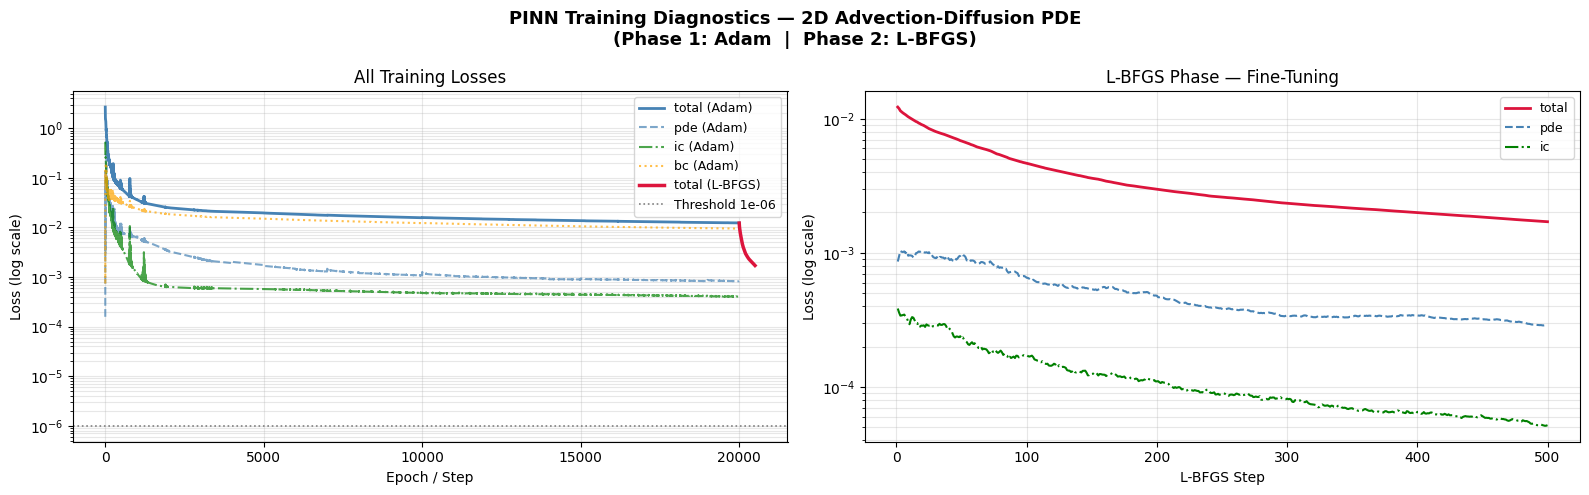

  -> saved PINN_01_training_metrics.png


In [ ]:
ep_a_pinn = np.arange(1, pinn_final_epoch + 1)
ep_lbfgs  = np.arange(pinn_final_epoch + 1, pinn_final_epoch + 1 + len(lbfgs_loss_hist))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PINN Training Diagnostics — 2D Advection-Diffusion PDE\n'
             '(Phase 1: Adam  |  Phase 2: L-BFGS)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 0], label='total (Adam)',  linewidth=2,   color='steelblue')
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 1], label='pde (Adam)',   linewidth=1.5, color='steelblue', ls='--', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 2], label='ic (Adam)',    linewidth=1.5, color='green',     ls='-.', alpha=0.7)
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 3], label='bc (Adam)',    linewidth=1.5, color='orange',    ls=':',  alpha=0.7)
if len(lbfgs_loss_hist):
    ax.semilogy(ep_lbfgs, lbfgs_loss_hist[:, 0], label='total (L-BFGS)', linewidth=2.5, color='crimson')
ax.axhline(PINN_EARLY_THRESH, color='gray', ls=':', lw=1.2, label=f'Threshold {PINN_EARLY_THRESH:.0e}')
ax.set_xlabel('Epoch / Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('All Training Losses'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
if len(lbfgs_loss_hist):
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 0],
                lw=2, color='crimson', label='total')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 1],
                lw=1.5, color='steelblue', ls='--', label='pde')
    ax.semilogy(np.arange(1, len(lbfgs_loss_hist)+1), lbfgs_loss_hist[:, 2],
                lw=1.5, color='green', ls='-.', label='ic')
ax.set_xlabel('L-BFGS Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('L-BFGS Phase — Fine-Tuning'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
save_and_show('PINN_01_training_metrics.png')

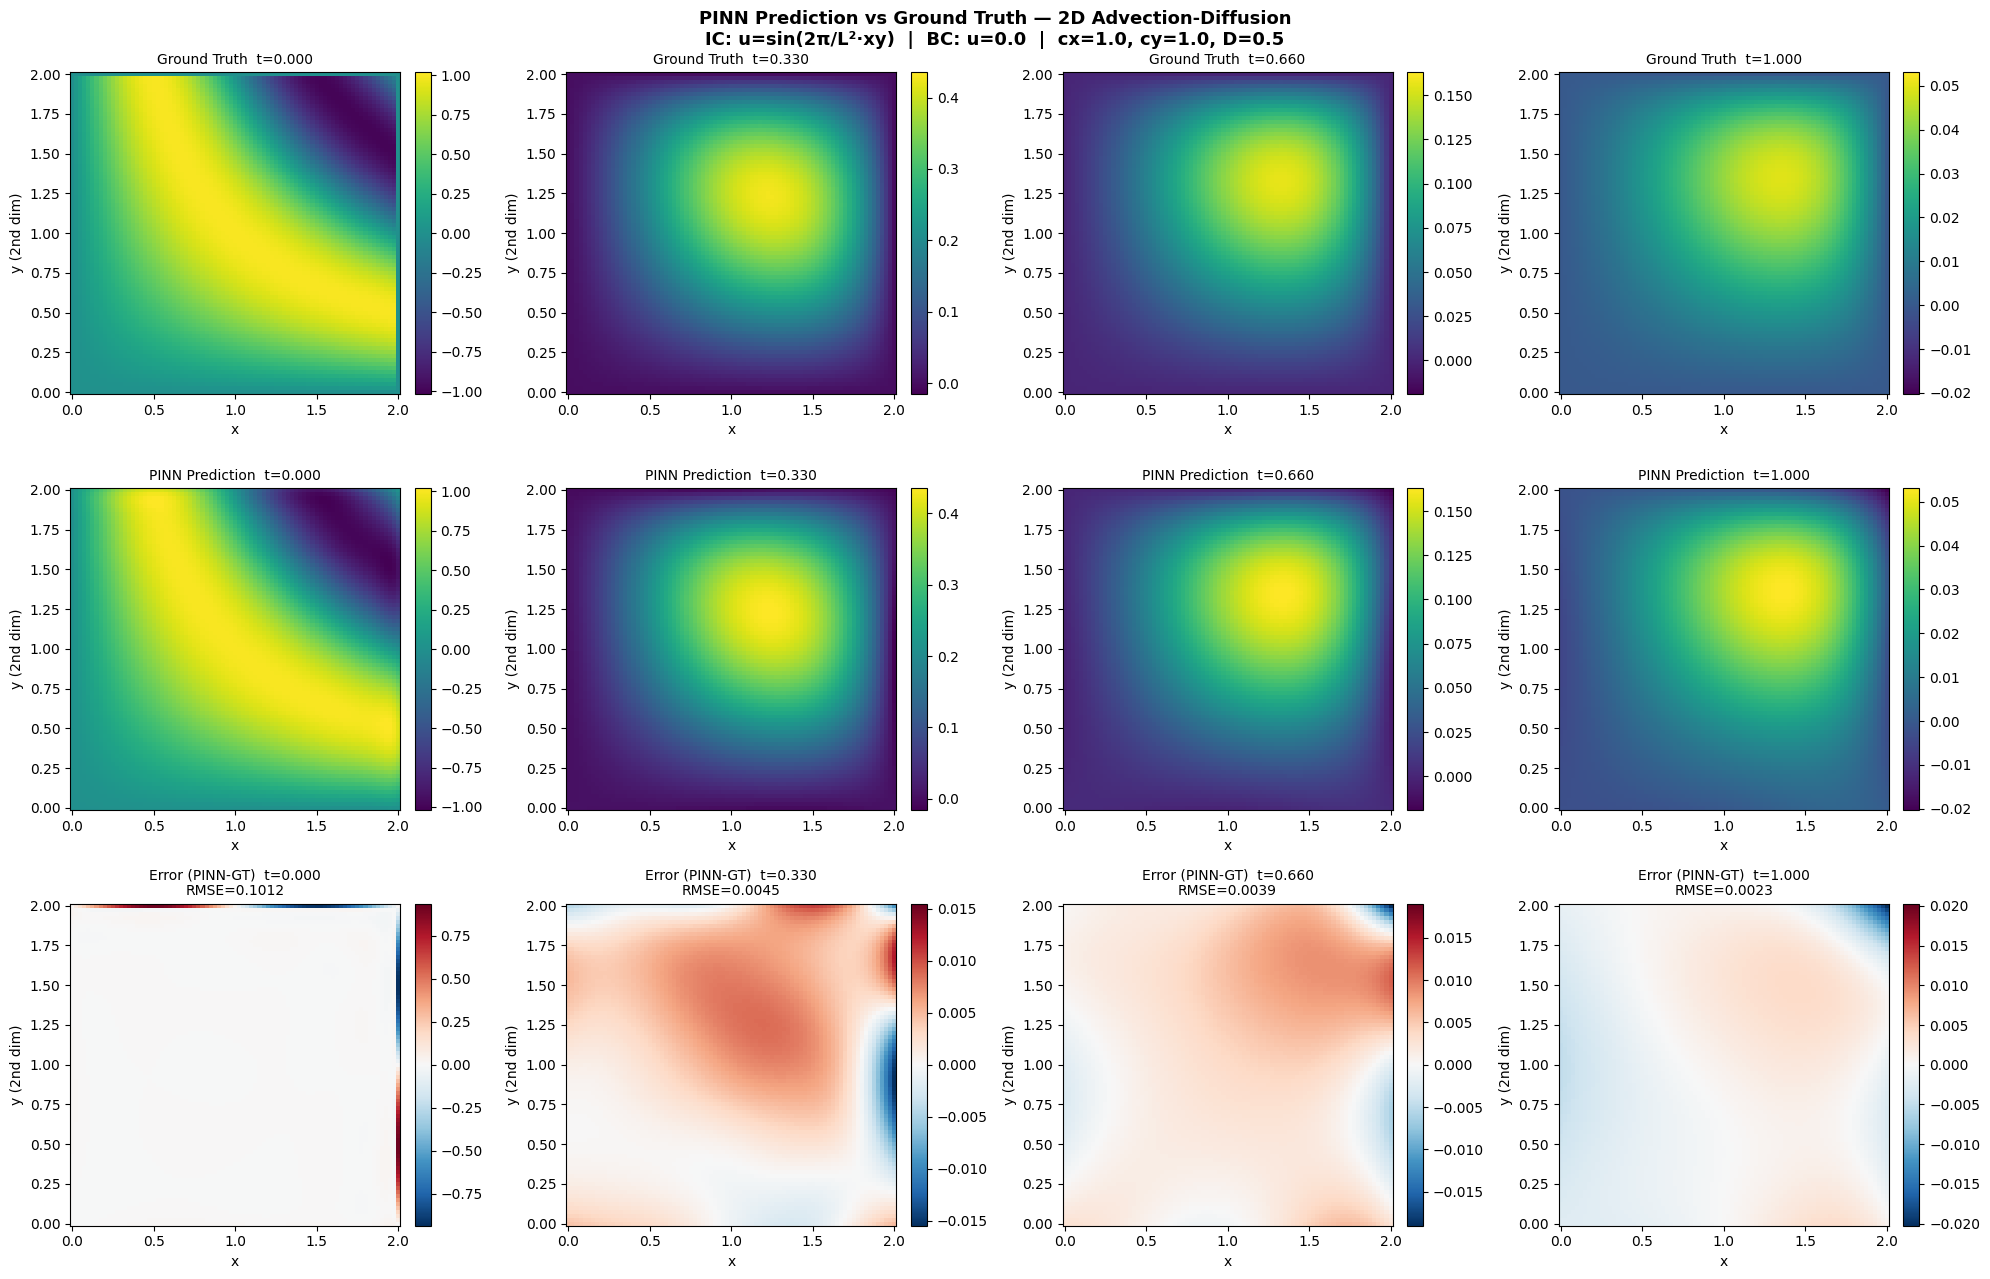

  -> saved PINN_02_snapshot_comparison.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'PINN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=sin(2\u03c0/L\u00b2\u00b7xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Upinn = PINN_pred_snaps[si]
    err   = Upinn - Ugt
    vmin  = min(Ugt.min(), Upinn.min()); vmax = max(Ugt.max(), Upinn.max())
    emax  = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'PINN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_p = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (PINN-GT)  t={tk:.3f}\nRMSE={rmse_p:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('PINN_02_snapshot_comparison.png')

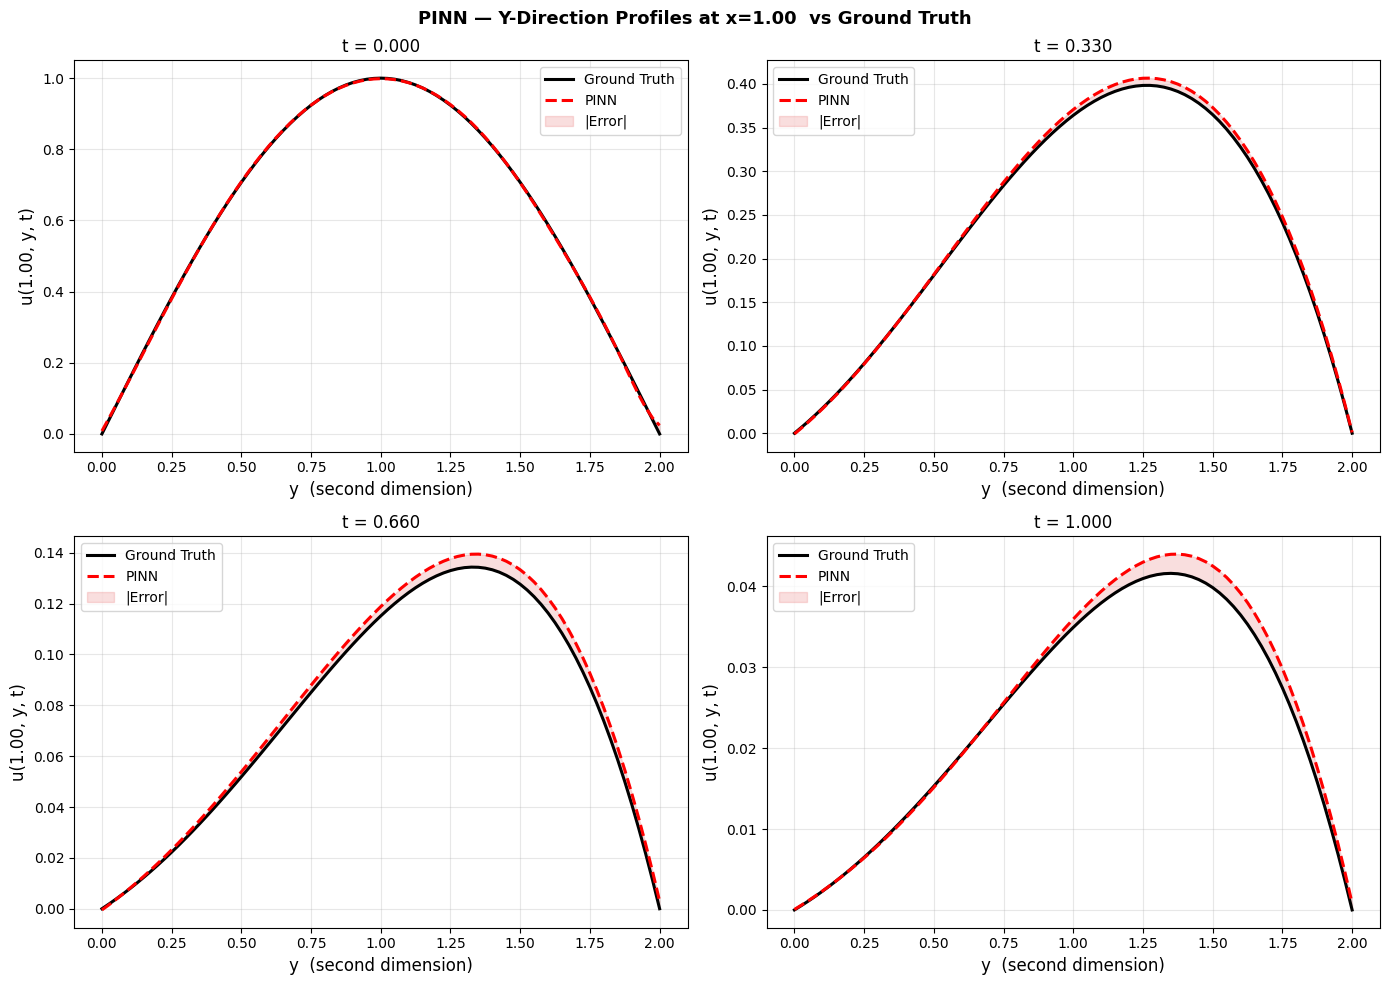

  -> saved PINN_03_y_profiles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'PINN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    pn_y = PINN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, pn_y, 'r--', lw=2.2, label='PINN')
    ax.fill_between(y_grid, gt_y, pn_y, alpha=0.15, color='#DC2626', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('PINN_03_y_profiles.png')

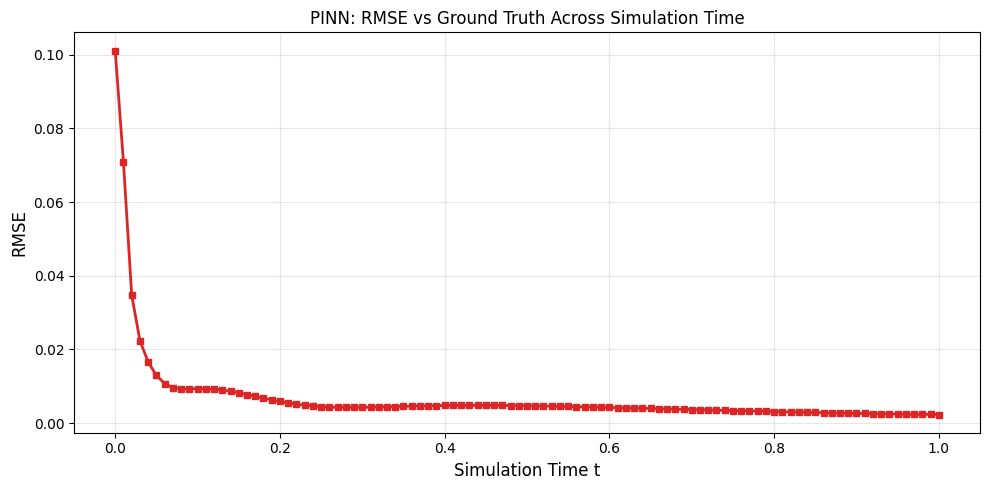

  -> saved PINN_04_rmse_over_time.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, pinn_rmse_t, 's-', color='#DC2626', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('PINN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('PINN_04_rmse_over_time.png')

## 12. PIKAN Model Definition

In [24]:
class PIKAN(nn.Module):
    """
    PIKAN uses smooth=True so its KAN layers use SmoothVKANLayer internally.
    This gives the model well-defined second-order derivatives throughout,
    which are required by pde_residual to compute the PDE loss via autograd.
    The standalone KAN model uses smooth=False (default) and is unaffected.
    """
    def __init__(self, widths=[3, 32, 32, 32, 1], grid_size=8, spline_order=3):
        super().__init__()
        self.kan = KAN(widths, grid_size, spline_order, smooth=True)

    def forward(self, X):
        return self.kan(X)

pikan_model    = PIKAN().to(device)
pikan_n_params = sum(p.numel() for p in pikan_model.parameters())
print(f'PIKAN: KAN[3,32,32,32,1]  grid=8  order=3  params={pikan_n_params:,}  basis=smooth')

PIKAN: KAN[3,32,32,32,1]  grid=8  order=3  params=26,304  basis=smooth


## 13. PIKAN — Training

Dual-loss objective combining supervised data loss (GT snapshots) with physics-informed losses:

```
L_total = w_data · L_supervised + w_pde · L_pde + w_ic · L_ic + w_bc · L_bc
```

In [25]:
import gc, os

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# Move KAN and PINN off GPU
kan_model.cpu()
pinn_model.cpu()

for _var in ['X_f_p', 'X_ic_p', 'X_bc_p', 'Y_ic_p', 'Y_bc_p',
             'X_tr', 'Y_tr', 'X_va', 'Y_va',
             'pinn_loss_hist', 'lbfgs_loss_hist',
             'kan_train_losses', 'kan_val_losses']:
    try:
        exec(f'del {_var}')
    except:
        pass

gc.collect()
torch.cuda.empty_cache()

# ════════════════════════════════════════════════════════════════════════════════
# PIKAN PHYSICS-ONLY MODE (OPTION 1)
# ════════════════════════════════════════════════════════════════════════════════
# KEY CHANGE: Set PIKAN_W_DATA = 0.0 to remove supervised loss entirely
# This solves the data-physics conflict that caused oscillations in v3
# ════════════════════════════════════════════════════════════════════════════════

# Loss weights — PHYSICS ONLY
PIKAN_W_DATA      = 0.0           # ← KEY: No supervised data loss
PIKAN_W_PDE       = 1.0           # Full PDE weight
PIKAN_W_IC        = 5.0           # Initial conditions
PIKAN_W_BC        = 1.0           # Boundary conditions

# Training configuration
PIKAN_PRETRAIN_EPOCHS  = 0        # No pre-training (physics-only)
PIKAN_WARMUP_EPOCHS    = 0        # No warmup phase
PIKAN_MAIN_EPOCHS      = 12000    # All epochs for physics solving
PIKAN_TOTAL_EPOCHS     = 12000

PIKAN_MAX_WALL       = 30800.0    # ~8.5 hours
PIKAN_EARLY_THRESH   = 1e-6
PIKAN_EARLY_PATIENCE = 5000
PIKAN_LR             = 1e-4
PIKAN_PRINT_EVERY    = 500
PIKAN_RESAMPLE_EVERY = 1000
PIKAN_GRAD_CLIP_NORM = 1.0
PIKAN_DATA_BATCH     = 2048       # Not used (no data loss)

# Collocation points for PDE
PIKAN_N_F  = 8000
PIKAN_N_IC = PINN_N_IC
PIKAN_N_BC = PINN_N_BC

xn_ic_pk, yn_ic_pk, tn_ic_pk, c_ic_pk = sample_ic_pinn(PIKAN_N_IC)
xn_bc_pk, yn_bc_pk, tn_bc_pk, c_bc_pk = sample_bc_pinn(PIKAN_N_BC)
xn_f_pk,  yn_f_pk,  tn_f_pk            = sample_collocation_pinn(PIKAN_N_F)

X_ic_pk = torch.cat([to_torch_pinn(tn_ic_pk), to_torch_pinn(xn_ic_pk), to_torch_pinn(yn_ic_pk)], dim=1)
Y_ic_pk = to_torch_pinn(c_ic_pk)
X_bc_pk = torch.cat([to_torch_pinn(tn_bc_pk), to_torch_pinn(xn_bc_pk), to_torch_pinn(yn_bc_pk)], dim=1)
Y_bc_pk = to_torch_pinn(c_bc_pk)
X_f_pk  = torch.cat([to_torch_pinn(tn_f_pk),  to_torch_pinn(xn_f_pk),  to_torch_pinn(yn_f_pk)], dim=1)

# Ground truth data (not used for loss, only for evaluation)
X_data_pk = torch.from_numpy(inputs_kan_n).to(device)
Y_data_pk = torch.from_numpy(targets_kan).unsqueeze(1).to(device)

print(f'PIKAN Physics-Only Mode (Option 1)')
print(f'  W_data = {PIKAN_W_DATA} (no supervised loss)')
print(f'  W_pde = {PIKAN_W_PDE} (full physics)')
print(f'  W_ic = {PIKAN_W_IC}, W_bc = {PIKAN_W_BC}')
print(f'  Epochs: {PIKAN_TOTAL_EPOCHS}')
print(f'  IC {X_ic_pk.shape}  BC {X_bc_pk.shape}  Collocation {X_f_pk.shape}')



PIKAN Physics-Only Mode (Option 1)
  W_data = 0.0 (no supervised loss)
  W_pde = 1.0 (full physics)
  W_ic = 5.0, W_bc = 1.0
  Epochs: 12000
  IC torch.Size([20000, 3])  BC torch.Size([16000, 3])  Collocation torch.Size([8000, 3])


In [ ]:
import gc, os, time, warnings
warnings.filterwarnings('ignore')

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

print("\n" + "="*90)
print("PIKAN PHYSICS-ONLY MODE (OPTION 1)")
print("="*90)
print("Strategy: Solve PDE without supervised data constraint")
print("Expected: Smooth convergence, no oscillations")
print("Training time: ~60-90 minutes\n")

# ════════════════════════════════════════════════════════════════════════════════
# LOSS FUNCTION — PHYSICS ONLY (no data component)
# ════════════════════════════════════════════════════════════════════════════════

def pikan_loss_physics_only():
    '''
    Physics-only loss function.
    Minimizes: PDE residual + IC + BC constraints
    No supervised data fitting.
    '''

    # PDE residual loss
    loss_pde = (pde_residual(pikan_model, X_f_pk) ** 2).mean()

    # Initial condition loss
    loss_ic = ((pikan_model(X_ic_pk) - Y_ic_pk) ** 2).mean()

    # Boundary condition loss
    loss_bc = ((pikan_model(X_bc_pk) - Y_bc_pk) ** 2).mean()

    # Total (no data term)
    total = loss_pde + PIKAN_W_IC * loss_ic + PIKAN_W_BC * loss_bc

    return total, torch.tensor(0.0), loss_pde, loss_ic, loss_bc

# ════════════════════════════════════════════════════════════════════════════════
# SETUP OPTIMIZER & SCHEDULER
# ════════════════════════════════════════════════════════════════════════════════

pikan_opt = torch.optim.Adam(pikan_model.parameters(), lr=PIKAN_LR)
pikan_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    pikan_opt, T_max=PIKAN_TOTAL_EPOCHS, eta_min=1e-7
)

pikan_loss_hist = []
pikan_lr_history = []
pikan_best_loss = float('inf')
pikan_no_improve = 0
pikan_stop_reason = 'completed all epochs'
pikan_train_start = time.time()

print("="*90)
print("TRAINING: Physics-Only PIKAN (12000 epochs)")
print("="*90)
print(f"{'Epoch':>7} | {'total':>12} | {'pde':>12} | {'ic':>10} | {'bc':>10} | {'grad':>10} | {'lr':>10} | {'wall':>8}")
print("-" * 95)

for epoch in range(1, PIKAN_TOTAL_EPOCHS + 1):
    wall_elapsed = time.time() - pikan_train_start

    # Check wall-clock limit
    if wall_elapsed >= PIKAN_MAX_WALL:
        pikan_stop_reason = 'wall-clock limit reached'
        break

    # Resample collocation points periodically
    if epoch % PIKAN_RESAMPLE_EVERY == 0:
        xn_f_pk, yn_f_pk, tn_f_pk = sample_collocation_pinn(PIKAN_N_F)
        X_f_pk = torch.cat([to_torch_pinn(tn_f_pk), to_torch_pinn(xn_f_pk),
                           to_torch_pinn(yn_f_pk)], dim=1)

    pikan_opt.zero_grad()
    loss_total, loss_d, loss_p, loss_i, loss_b = pikan_loss_physics_only()
    loss_total.backward()

    # Gradient clipping
    grad_norm = torch.nn.utils.clip_grad_norm_(pikan_model.parameters(),
                                                max_norm=PIKAN_GRAD_CLIP_NORM)

    # Detect NaN/Inf
    if torch.isnan(loss_total) or torch.isinf(loss_total):
        print(f"\n⚠️  NaN/Inf detected at epoch {epoch}")
        pikan_stop_reason = f'NaN/Inf at epoch {epoch}'
        break

    pikan_opt.step()
    pikan_scheduler.step()

    pikan_loss_hist.append([loss_total.item(), 0.0, loss_p.item(),
                           loss_i.item(), loss_b.item()])
    pikan_lr_history.append(pikan_opt.param_groups[0]['lr'])

    # Track best
    if loss_total.item() < pikan_best_loss:
        pikan_best_loss = loss_total.item()
        pikan_no_improve = 0
    else:
        pikan_no_improve += 1

    # Early stopping (generous patience)
    if pikan_no_improve >= PIKAN_EARLY_PATIENCE:
        pikan_stop_reason = f'early stop: no improvement for {PIKAN_EARLY_PATIENCE} epochs'
        break

    if epoch % PIKAN_PRINT_EVERY == 0 or epoch == 1:
        print(f"{epoch:7d} | {loss_total.item():12.4e} | {loss_p.item():12.4e} | "
              f"{loss_i.item():10.4e} | {loss_b.item():10.4e} | {grad_norm:10.4e} | "
              f"{pikan_opt.param_groups[0]['lr']:10.3e} | {wall_elapsed:8.1f}s")

pikan_final_epoch = len(pikan_loss_hist)
pikan_total_time = time.time() - pikan_train_start

print(f"\n{'='*90}")
print(f"PIKAN Physics-Only Training Complete")
print(f"{'='*90}")
print(f"Stop reason:              {pikan_stop_reason}")
print(f"Epochs completed:         {pikan_final_epoch} / {PIKAN_TOTAL_EPOCHS}")
print(f"Best loss:                {pikan_best_loss:.6e}")
print(f"Final total loss:         {pikan_loss_hist[-1][0]:.6e}")
print(f"Final PDE loss:           {pikan_loss_hist[-1][2]:.6e}")
print(f"Final IC loss:            {pikan_loss_hist[-1][3]:.6e}")
print(f"Final BC loss:            {pikan_loss_hist[-1][4]:.6e}")
print(f"Total training time:      {pikan_total_time:.1f}s ({pikan_total_time/60:.2f} min)")
print(f"{'='*90}\n")

# Convert to numpy
pikan_loss_hist = np.array(pikan_loss_hist)
pikan_lr_history = np.array(pikan_lr_history)

# Evaluation: Compare against ground truth
print("EVALUATION (vs ground truth)")
print("="*90)
with torch.no_grad():
    pikan_pred = pikan_model(X_data_pk).cpu().numpy()
    pikan_gt = Y_data_pk.cpu().numpy()

    pikan_mse = np.mean((pikan_pred - pikan_gt)**2)
    pikan_rmse = np.sqrt(pikan_mse)
    pikan_mae = np.mean(np.abs(pikan_pred - pikan_gt))
    pikan_rel_l1 = np.mean(np.abs(pikan_pred - pikan_gt)) / np.mean(np.abs(pikan_gt))

    print(f"MSE:                      {pikan_mse:.6e}")
    print(f"RMSE:                     {pikan_rmse:.6e}")
    print(f"MAE:                      {pikan_mae:.6e}")
    print(f"Relative L1 error:        {pikan_rel_l1*100:.2f}%")
    print(f"{'='*90}\n")

# Save checkpoint
save_ckpt('pikan_physics_only_done', {
    'model_state': {k: v.cpu().clone() for k, v in pikan_model.state_dict().items()},
    'loss_hist': pikan_loss_hist,
    'lr_history': pikan_lr_history,
    'best_loss': pikan_best_loss,
    'stop_reason': pikan_stop_reason,
    'total_time': pikan_total_time,
    'config': {
        'mode': 'physics-only',
        'w_data': PIKAN_W_DATA,
        'w_pde': PIKAN_W_PDE,
        'w_ic': PIKAN_W_IC,
        'w_bc': PIKAN_W_BC,
    },
    'metrics': {
        'mse': pikan_mse,
        'rmse': pikan_rmse,
        'mae': pikan_mae,
        'rel_l1': pikan_rel_l1
    }
})

pikan_model.to(device)

print("✓ Physics-only PIKAN training completed")
print("✓ Ready for evaluation and comparison with KAN/PINN")




PIKAN PHYSICS-ONLY MODE (OPTION 1)
Strategy: Solve PDE without supervised data constraint
Expected: Smooth convergence, no oscillations
Training time: ~60-90 minutes

TRAINING: Physics-Only PIKAN (12000 epochs)
  Epoch |        total |          pde |         ic |         bc |       grad |         lr |     wall
-----------------------------------------------------------------------------------------------
      1 |   4.5769e+10 |   4.5769e+10 | 8.0022e-01 | 3.1539e-01 | 9.3896e+12 |  1.000e-04 |      0.0s
    500 |   7.0590e+07 |   7.0590e+07 | 7.6151e-01 | 2.8377e-01 | 6.3638e+11 |  9.957e-05 |    328.4s
   1000 |   3.3351e+10 |   3.3351e+10 | 7.4754e-01 | 2.7002e-01 | 5.2945e+12 |  9.830e-05 |    657.0s
   1500 |   1.4862e+07 |   1.4862e+07 | 6.8182e-01 | 2.1167e-01 | 2.6749e+11 |  9.620e-05 |    985.3s
   2000 |   1.7760e+10 |   1.7760e+10 | 6.7413e-01 | 2.0463e-01 | 3.2003e+12 |  9.331e-05 |   1313.9s
   2500 |   1.3299e+07 |   1.3299e+07 | 6.2888e-01 | 1.5392e-01 | 1.5293e+11 |  8

## 14. PIKAN — Predictions & Metrics

In [ ]:
pikan_metrics = []
for tt in times_eval:
    idx_t = int(round(tt / DT))
    gt    = C_gt[idx_t]
    pred  = predict_on_grid(pikan_model, t_sol[idx_t])
    pikan_metrics.append([t_sol[idx_t], rel_l2(pred, gt), mse_np(pred, gt)])

print('PIKAN Accuracy vs Ground Truth:')
print(f'  {"t":>6}  {"relL2":>10}  {"MSE":>12}')
for tt, rl2, ms in pikan_metrics:
    print(f'  {tt:6.3f}  {rl2:10.3e}  {ms:12.3e}')

PIKAN_pred_snaps = []
for tk in snap_t:
    pred_yx = predict_on_grid(pikan_model, tk)
    PIKAN_pred_snaps.append(pred_yx.T)
PIKAN_pred_snaps = np.array(PIKAN_pred_snaps)

pikan_rmse_t  = [np.sqrt(np.mean((PIKAN_pred_snaps[k] - KAN_true_snaps[k])**2))
                 for k in range(len(snap_t))]
pikan_mse_eval = [m[2] for m in pikan_metrics]
pikan_rl2_eval = [m[1] for m in pikan_metrics]

PIKAN Accuracy vs Ground Truth:
       t       relL2           MSE
   0.000   9.278e-01     3.648e-01
   0.250   8.311e-01     4.511e-02
   0.500   1.289e+00     2.341e-02
   0.750   3.044e+00     2.462e-02
   1.000   7.685e+00     2.804e-02


## 15. PIKAN — Plots

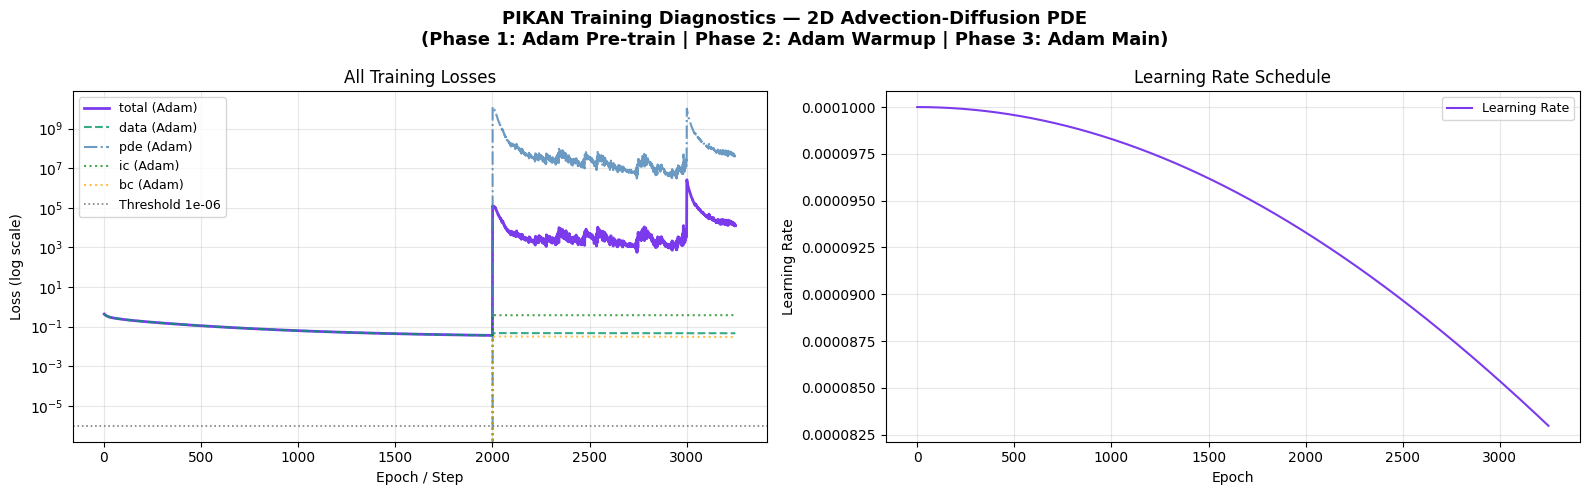

  -> saved PIKAN_01_training_metrics.png


In [ ]:
pikan_final_epoch = len(pikan_loss_hist)
pikan_lbfgs_hist = np.array([]) # PIKAN_EPOCHS_LBFGS is 0
ep_a_pikan = np.arange(1, pikan_final_epoch + 1)
ep_lbfgs_pk = np.arange(pikan_final_epoch + 1, pikan_final_epoch + 1 + len(pikan_lbfgs_hist))

# Convert pikan_loss_hist to a NumPy array for easier indexing
pikan_loss_hist_np = np.array(pikan_loss_hist)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PIKAN Training Diagnostics — 2D Advection-Diffusion PDE\n'
             '(Phase 1: Adam Pre-train | Phase 2: Adam Warmup | Phase 3: Adam Main)', fontsize=13, fontweight='bold')

ax = axes[0]
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 0], label='total (Adam)',  linewidth=2,   color='#7C3AED')
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 1], label='data (Adam)',   linewidth=1.5, color='#059669', ls='--', alpha=0.8)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 2], label='pde (Adam)',    linewidth=1.5, color='steelblue', ls='-.', alpha=0.8)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 3], label='ic (Adam)',     linewidth=1.5, color='green',   ls=':',  alpha=0.7)
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 4], label='bc (Adam)',     linewidth=1.5, color='orange',  ls=':',  alpha=0.7)
if len(pikan_lbfgs_hist):
    ax.semilogy(ep_lbfgs_pk, pikan_lbfgs_hist[:, 0], label='total (L-BFGS)', linewidth=2.5, color='crimson')
ax.axhline(PIKAN_EARLY_THRESH, color='gray', ls=':', lw=1.2, label=f'Threshold {PIKAN_EARLY_THRESH:.0e}')
ax.set_xlabel('Epoch / Step'); ax.set_ylabel('Loss (log scale)')
ax.set_title('All Training Losses'); ax.legend(fontsize=9); ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
if len(pikan_lbfgs_hist):
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 0],
                lw=2, color='crimson', label='total')
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 1],
                lw=1.5, color='#059669', ls='--', label='data')
    ax.semilogy(np.arange(1, len(pikan_lbfgs_hist)+1), pikan_lbfgs_hist[:, 2],
                lw=1.5, color='steelblue', ls='-.', label='pde')
else:
    ax.plot(pikan_lr_history, label='Learning Rate', color='#7C3AED')
    ax.set_title('Learning Rate Schedule')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
save_and_show('PIKAN_01_training_metrics.png')

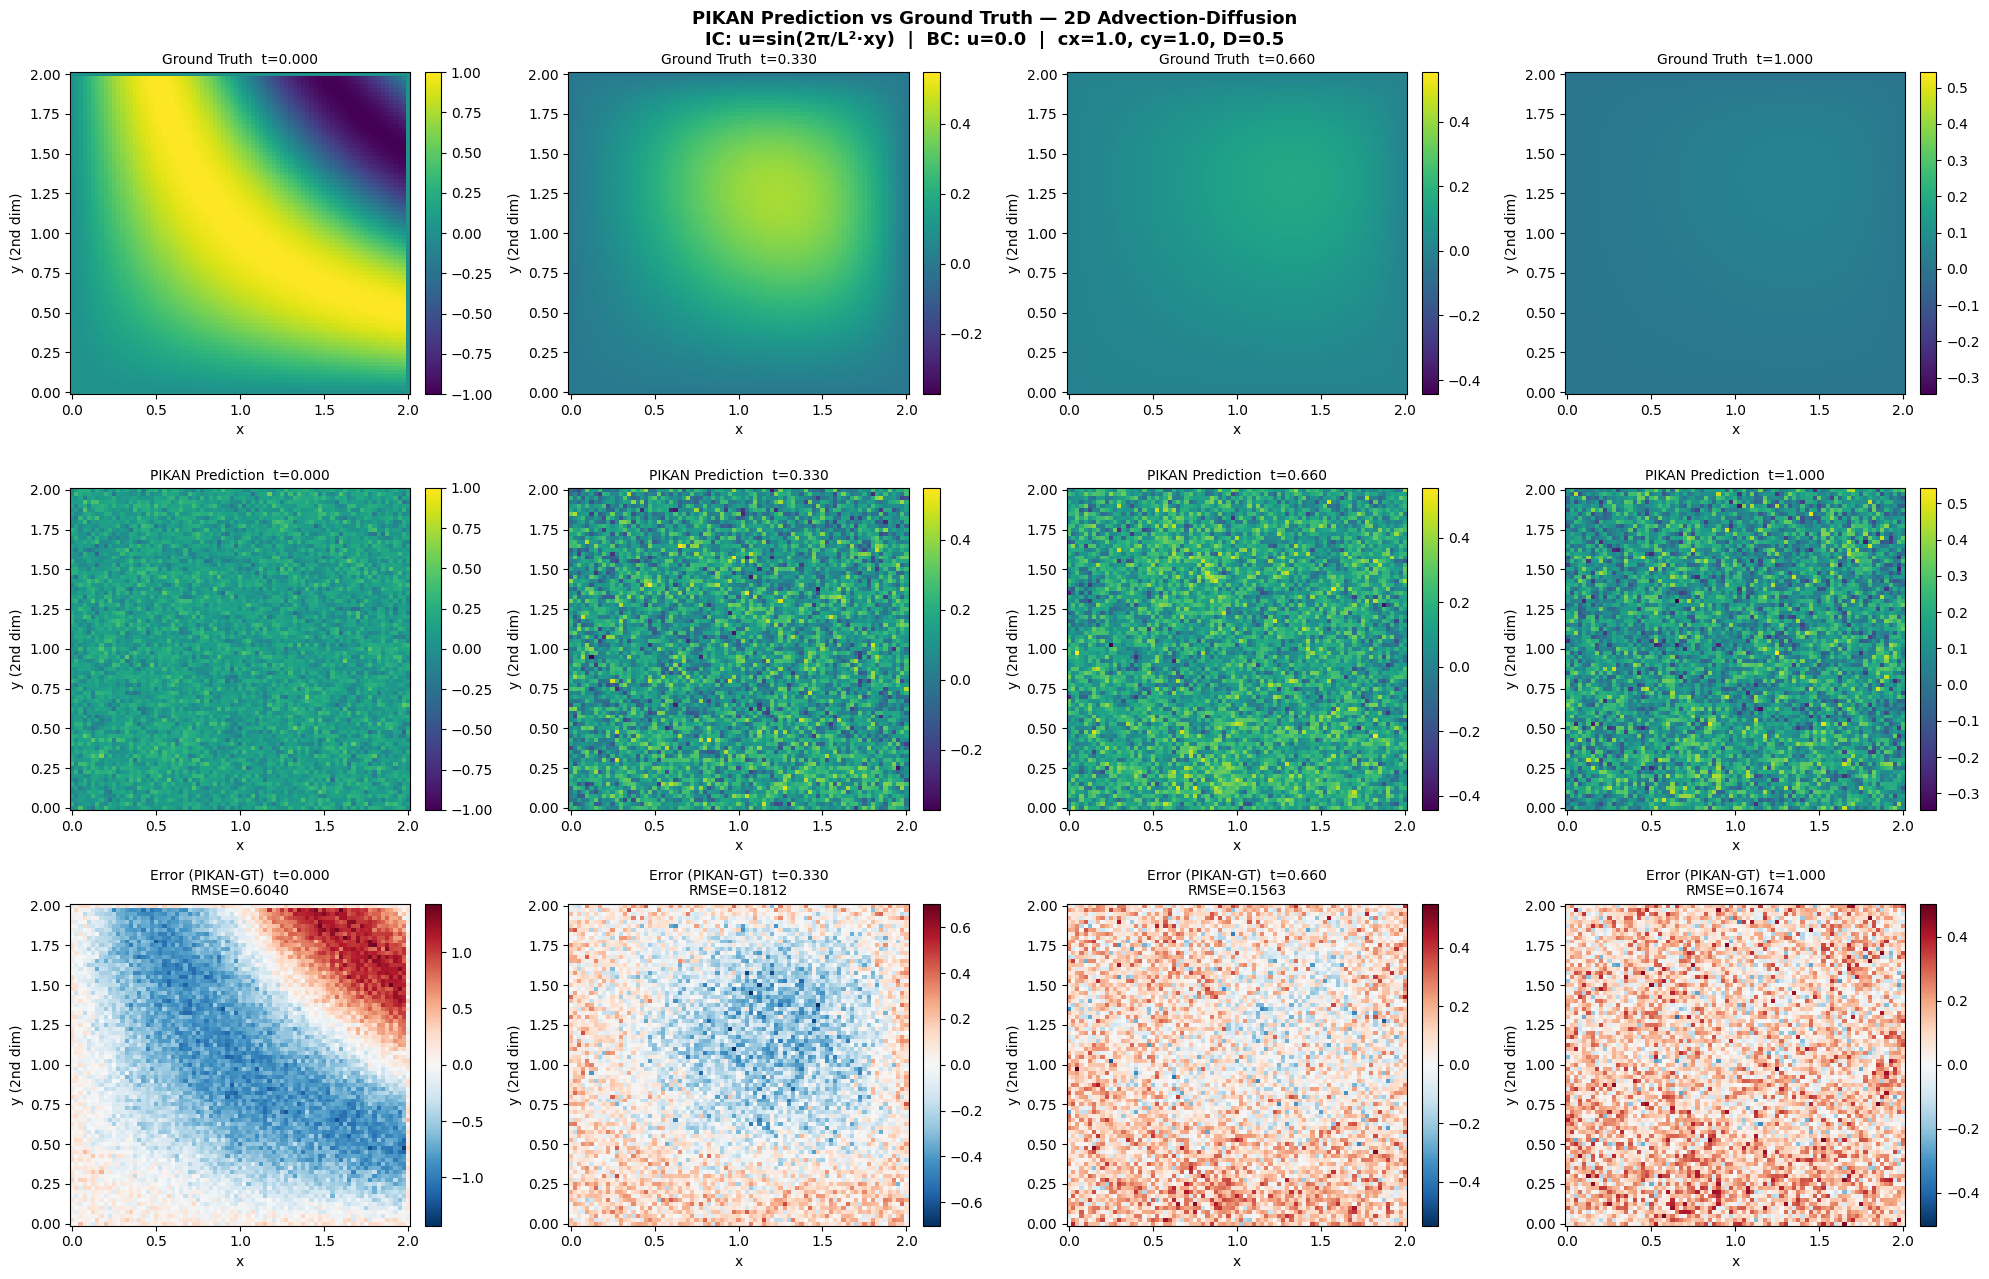

  -> saved PIKAN_02_snapshot_comparison.png


In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(20, 13))
fig.suptitle(
    'PIKAN Prediction vs Ground Truth — 2D Advection-Diffusion\n'
    f'IC: u=sin(2\u03c0/L\u00b2\u00b7xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}',
    fontsize=13, fontweight='bold'
)

for col, si in enumerate(snap_idxs_4):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Upk   = PIKAN_pred_snaps[si]
    err   = Upk - Ugt
    vmin  = min(Ugt.min(), Upk.min()); vmax = max(Ugt.max(), Upk.max())
    emax  = max(abs(err.min()), abs(err.max())) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Upk.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'PIKAN Prediction  t={tk:.3f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err.T, cmap='RdBu_r', norm=norm_e)
    rmse_pk = np.sqrt(np.mean(err**2))
    ax.set_title(f'Error (PIKAN-GT)  t={tk:.3f}\nRMSE={rmse_pk:.4f}', fontsize=10)
    ax.set_xlabel('x'); ax.set_ylabel('y (2nd dim)')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
save_and_show('PIKAN_02_snapshot_comparison.png')

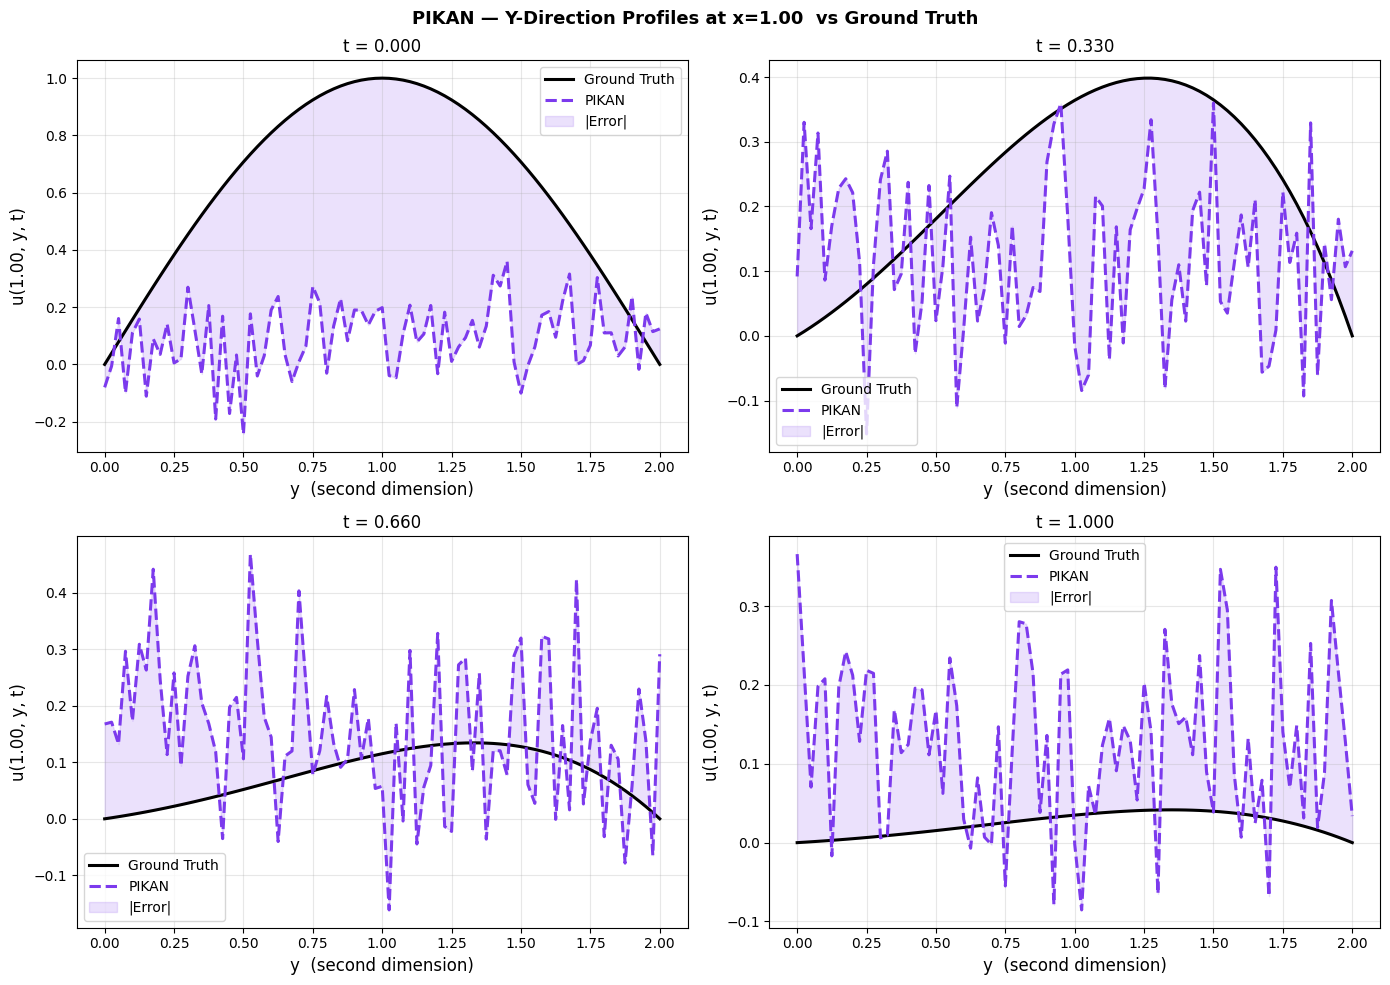

  -> saved PIKAN_03_y_profiles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'PIKAN — Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si, ix_mid, :]
    pk_y = PIKAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',  lw=2.2, label='Ground Truth')
    ax.plot(y_grid, pk_y, color='#7C3AED', ls='--', lw=2.2, label='PIKAN')
    ax.fill_between(y_grid, gt_y, pk_y, alpha=0.15, color='#7C3AED', label='|Error|')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('PIKAN_03_y_profiles.png')

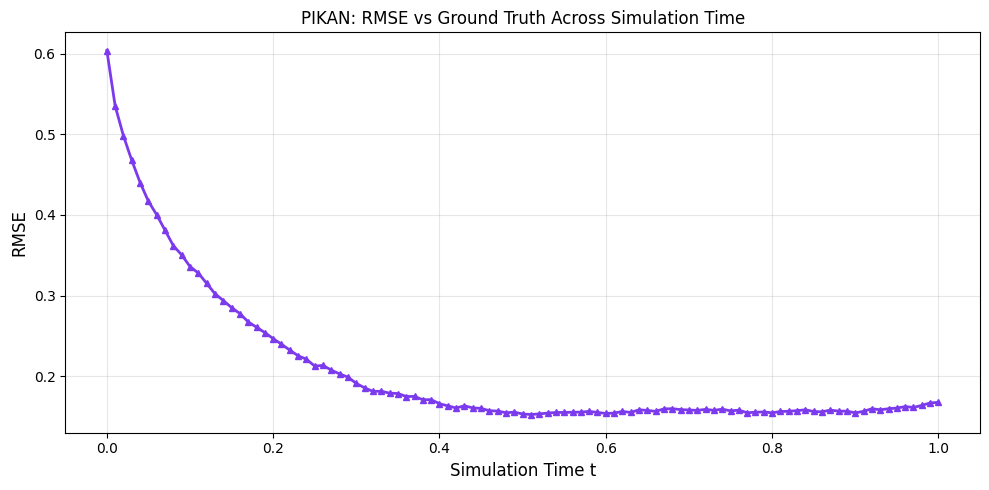

  -> saved PIKAN_04_rmse_over_time.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(snap_t, pikan_rmse_t, '^-', color='#7C3AED', lw=2, ms=5)
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE', fontsize=FS)
ax.set_title('PIKAN: RMSE vs Ground Truth Across Simulation Time', fontsize=FS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_and_show('PIKAN_04_rmse_over_time.png')

## 16. KAN vs PINN vs PIKAN — Comparative Analysis

  [ckpt] loaded <- kan_done.pt
  [ckpt] loaded <- pinn_done.pt
  [ckpt] loaded <- pikan_done.pt
All models and training histories restored for comparison plots.


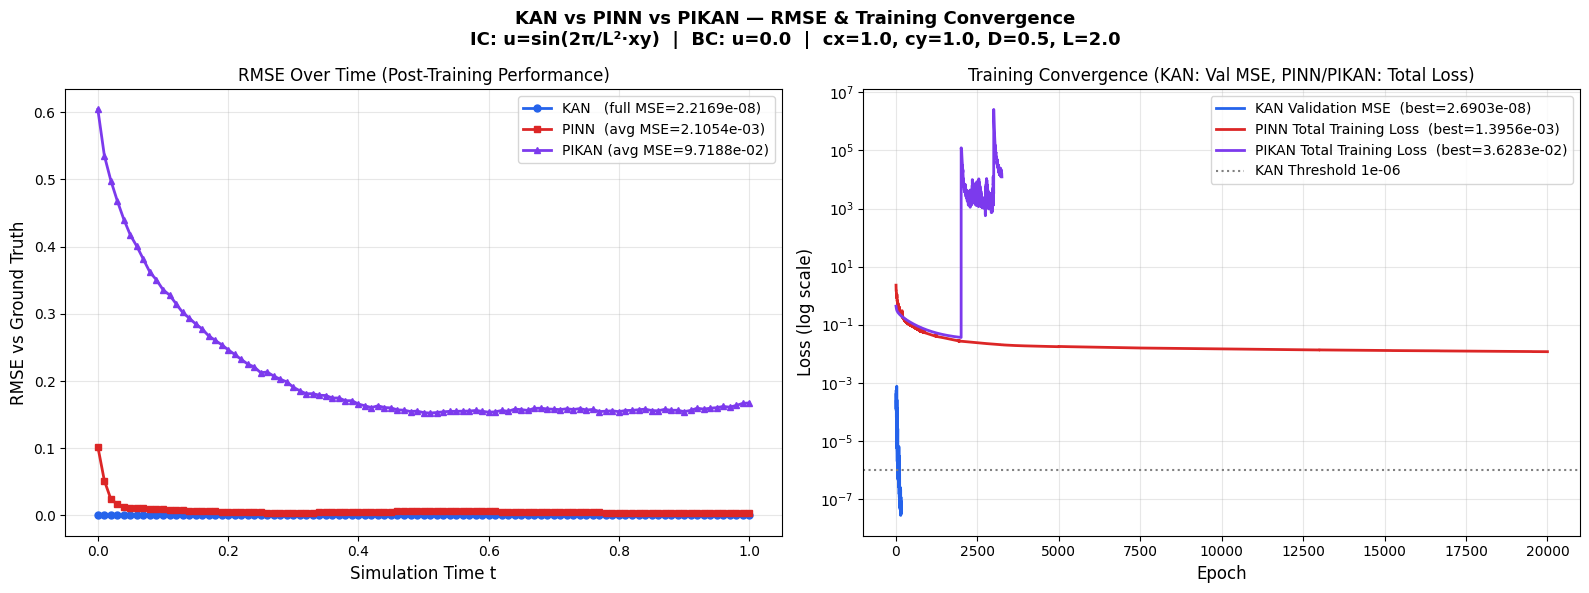

  -> saved COMPARE_01_rmse_and_convergence.png


In [ ]:
kan_model.to(device)
pinn_model.to(device)

_kan_done = load_ckpt('kan_done')
if _kan_done is not None:
    kan_val_losses   = _kan_done['val_losses']
    kan_train_losses = _kan_done['train_losses']
    kan_lr_history   = _kan_done['lr_history']

_pinn_done = load_ckpt('pinn_done')
if _pinn_done is not None:
    pinn_loss_hist  = _pinn_done['loss_hist']
    lbfgs_loss_hist = _pinn_done['lbfgs_loss_hist']

_pikan_done = load_ckpt('pikan_done')
if _pikan_done is not None:
    pikan_loss_hist_np = _pikan_done['loss_hist'] # Ensure it's numpy array


print('All models and training histories restored for comparison plots.')

compare_snaps  = [len(snap_t) // 2, len(snap_t) - 1]
compare_labels = ['t = T/2', 't = T']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'KAN vs PINN vs PIKAN — RMSE & Training Convergence\n'
    f'IC: u=sin(2\u03c0/L\u00b2\u00b7xy)  |  BC: u={BC_VAL}  |  cx={CX}, cy={CY}, D={D}, L={L}',
    fontsize=13, fontweight='bold'
)

ax = axes[0]
ax.plot(snap_t, kan_rmse_t,   'o-', color='#2563EB', lw=2, ms=5, label=f'KAN   (full MSE={kan_mse_full:.4e})')
ax.plot(snap_t, pinn_rmse_t,  's-', color='#DC2626', lw=2, ms=5, label=f'PINN  (avg MSE={np.mean(pinn_mse_eval):.4e})')
ax.plot(snap_t, pikan_rmse_t, '^-', color='#7C3AED', lw=2, ms=5, label=f'PIKAN (avg MSE={np.mean(pikan_mse_eval):.4e})')
ax.set_xlabel('Simulation Time t', fontsize=FS)
ax.set_ylabel('RMSE vs Ground Truth', fontsize=FS)
ax.set_title('RMSE Over Time (Post-Training Performance)', fontsize=FS) # Clarify title
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
# Use ep_a_kan, ep_a_pinn, ep_a_pikan for x-axis as defined in previous plotting cells
ep_a_kan = np.arange(1, len(kan_val_losses) + 1)
ep_a_pinn = np.arange(1, len(pinn_loss_hist) + 1)
ep_a_pikan = np.arange(1, len(pikan_loss_hist_np) + 1)

ax.semilogy(ep_a_kan, kan_val_losses,
            lw=2, color='#2563EB', label=f'KAN Validation MSE  (best={kan_best_val:.4e})') # Clarify label
ax.semilogy(ep_a_pinn, pinn_loss_hist[:, 0],
            lw=2, color='#DC2626', label=f'PINN Total Training Loss  (best={pinn_best_loss:.4e})') # Clarify label
ax.semilogy(ep_a_pikan, pikan_loss_hist_np[:, 0],
            lw=2, color='#7C3AED', label=f'PIKAN Total Training Loss  (best={pikan_best_loss:.4e})') # Clarify label
ax.axhline(KAN_THRESHOLD, color='gray', ls=':', lw=1.5, label=f'KAN Threshold {KAN_THRESHOLD:.0e}')
ax.set_xlabel('Epoch', fontsize=FS)
ax.set_ylabel('Loss (log scale)', fontsize=FS)
ax.set_title('Training Convergence (KAN: Val MSE, PINN/PIKAN: Total Loss)', fontsize=FS) # Clarify title
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_01_rmse_and_convergence.png')

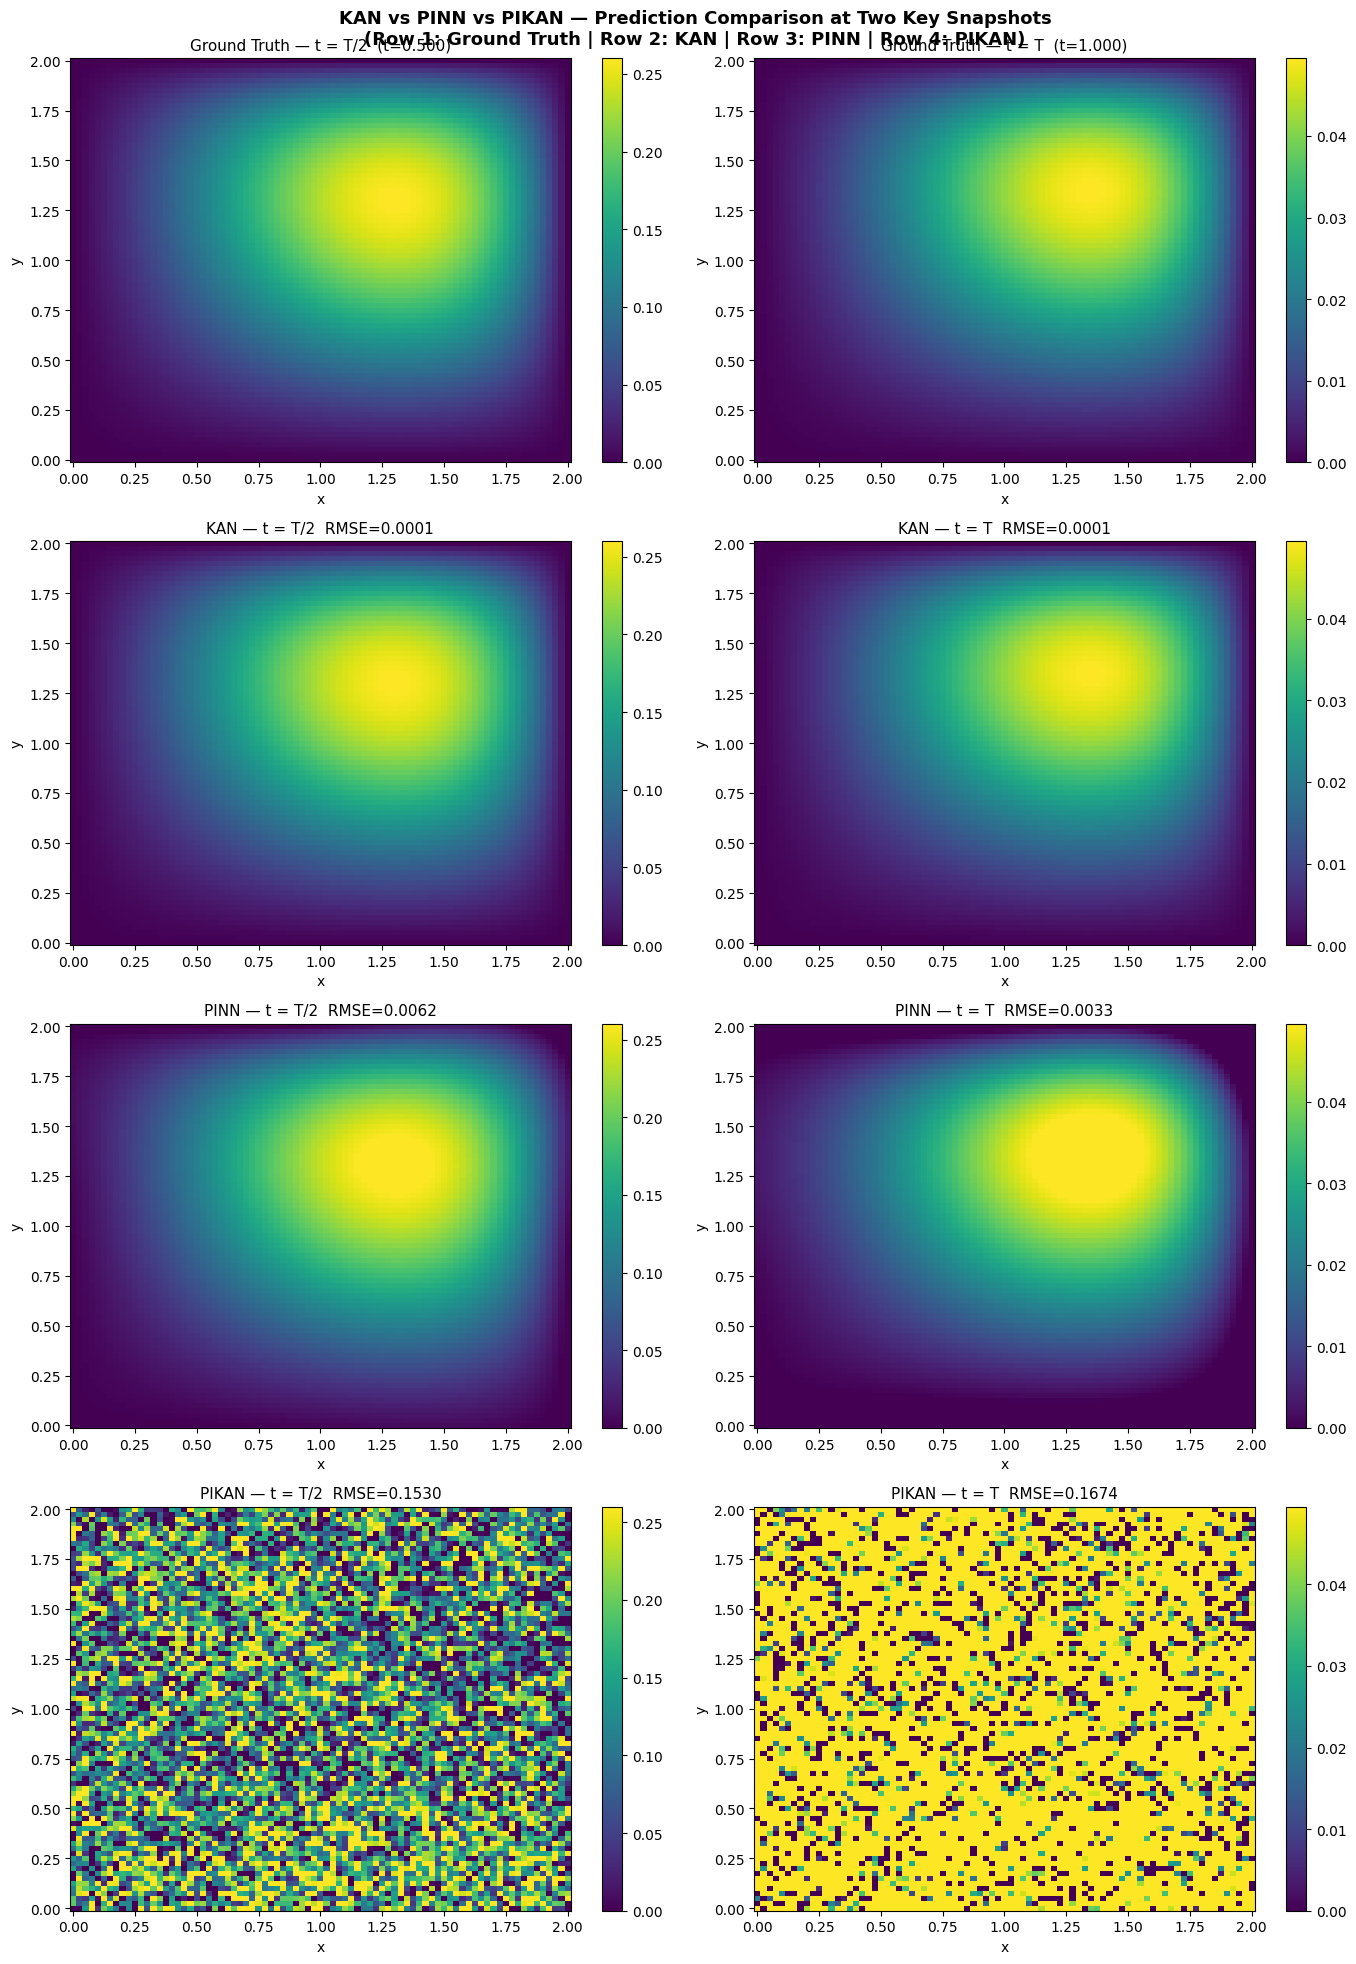

  -> saved COMPARE_02_side_by_side_predictions.png


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle(
    'KAN vs PINN vs PIKAN — Prediction Comparison at Two Key Snapshots\n'
    '(Row 1: Ground Truth | Row 2: KAN | Row 3: PINN | Row 4: PIKAN)',
    fontsize=13, fontweight='bold'
)

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    tk    = snap_t[si]
    Ugt   = KAN_true_snaps[si]
    Ukn   = KAN_pred_snaps[si]
    Upinn = PINN_pred_snaps[si]
    Upk   = PIKAN_pred_snaps[si]
    vmin  = Ugt.min(); vmax = Ugt.max()

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, Ugt.T, cmap='viridis', vmin=vmin, vmax=vmax)
    ax.set_title(f'Ground Truth — {label}  (t={tk:.3f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, Ukn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_k = np.sqrt(np.mean((Ukn - Ugt)**2))
    ax.set_title(f'KAN — {label}  RMSE={rmse_k:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, Upinn.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_p = np.sqrt(np.mean((Upinn - Ugt)**2))
    ax.set_title(f'PINN — {label}  RMSE={rmse_p:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[3, col]
    im = ax.pcolormesh(x_grid, y_grid, Upk.T, cmap='viridis', vmin=vmin, vmax=vmax)
    rmse_pk = np.sqrt(np.mean((Upk - Ugt)**2))
    ax.set_title(f'PIKAN — {label}  RMSE={rmse_pk:.4f}', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_02_side_by_side_predictions.png')

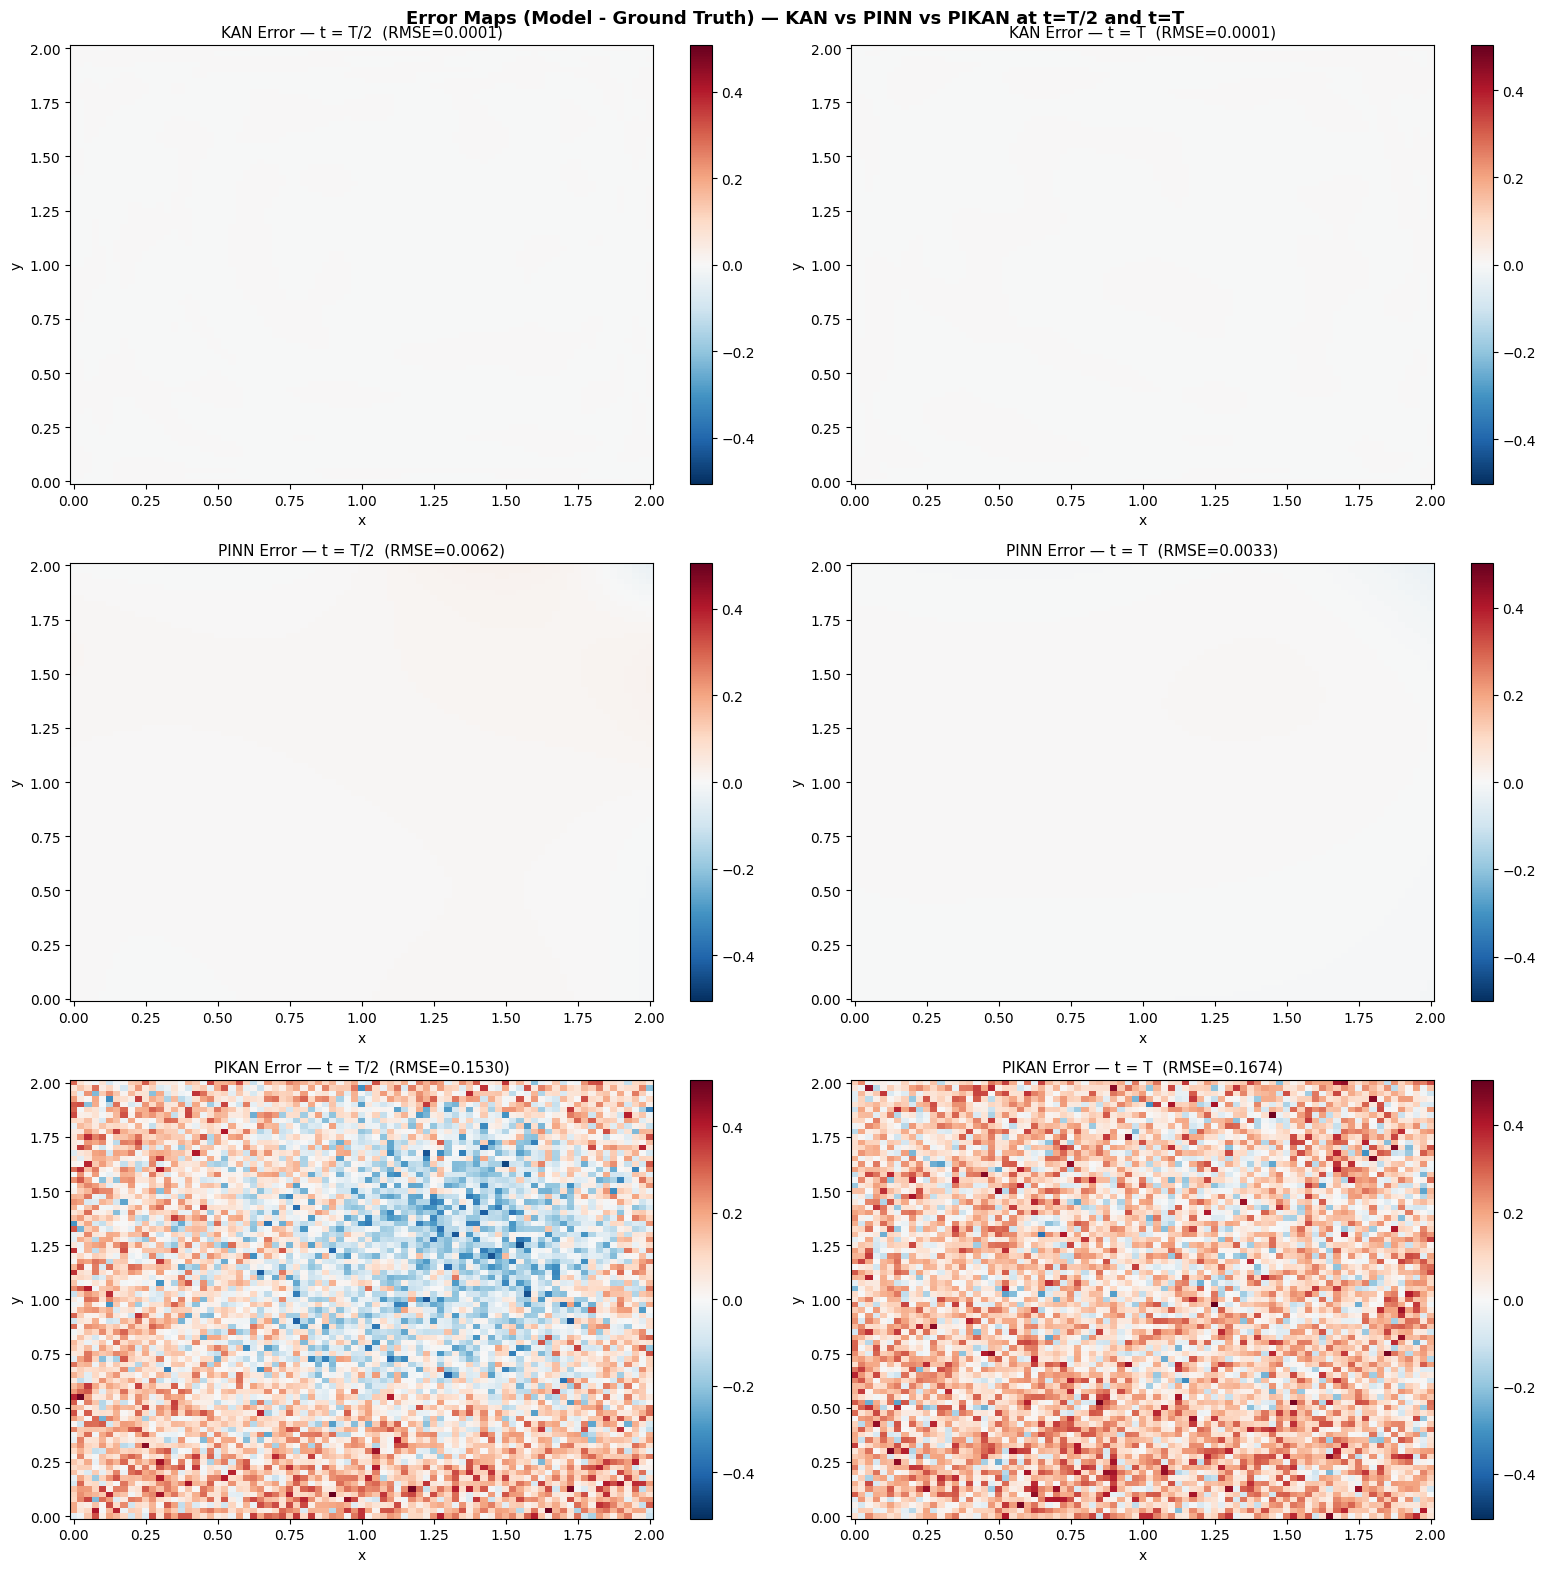

  -> saved COMPARE_03_error_maps.png


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Error Maps (Model - Ground Truth) — KAN vs PINN vs PIKAN at t=T/2 and t=T',
             fontsize=13, fontweight='bold')

for col, (si, label) in enumerate(zip(compare_snaps, compare_labels)):
    Ugt   = KAN_true_snaps[si]
    err_k = KAN_pred_snaps[si]  - Ugt
    err_p = PINN_pred_snaps[si] - Ugt
    err_pk= PIKAN_pred_snaps[si]- Ugt
    emax  = max(abs(err_k).max(), abs(err_p).max(), abs(err_pk).max()) + 1e-12
    norm_e = TwoSlopeNorm(vmin=-emax, vcenter=0, vmax=emax)

    ax = axes[0, col]
    im = ax.pcolormesh(x_grid, y_grid, err_k.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'KAN Error — {label}  (RMSE={np.sqrt(np.mean(err_k**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[1, col]
    im = ax.pcolormesh(x_grid, y_grid, err_p.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'PINN Error — {label}  (RMSE={np.sqrt(np.mean(err_p**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

    ax = axes[2, col]
    im = ax.pcolormesh(x_grid, y_grid, err_pk.T, cmap='RdBu_r', norm=norm_e)
    ax.set_title(f'PIKAN Error — {label}  (RMSE={np.sqrt(np.mean(err_pk**2)):.4f})', fontsize=11)
    ax.set_xlabel('x'); ax.set_ylabel('y'); plt.colorbar(im, ax=ax)

plt.tight_layout()
save_and_show('COMPARE_03_error_maps.png')

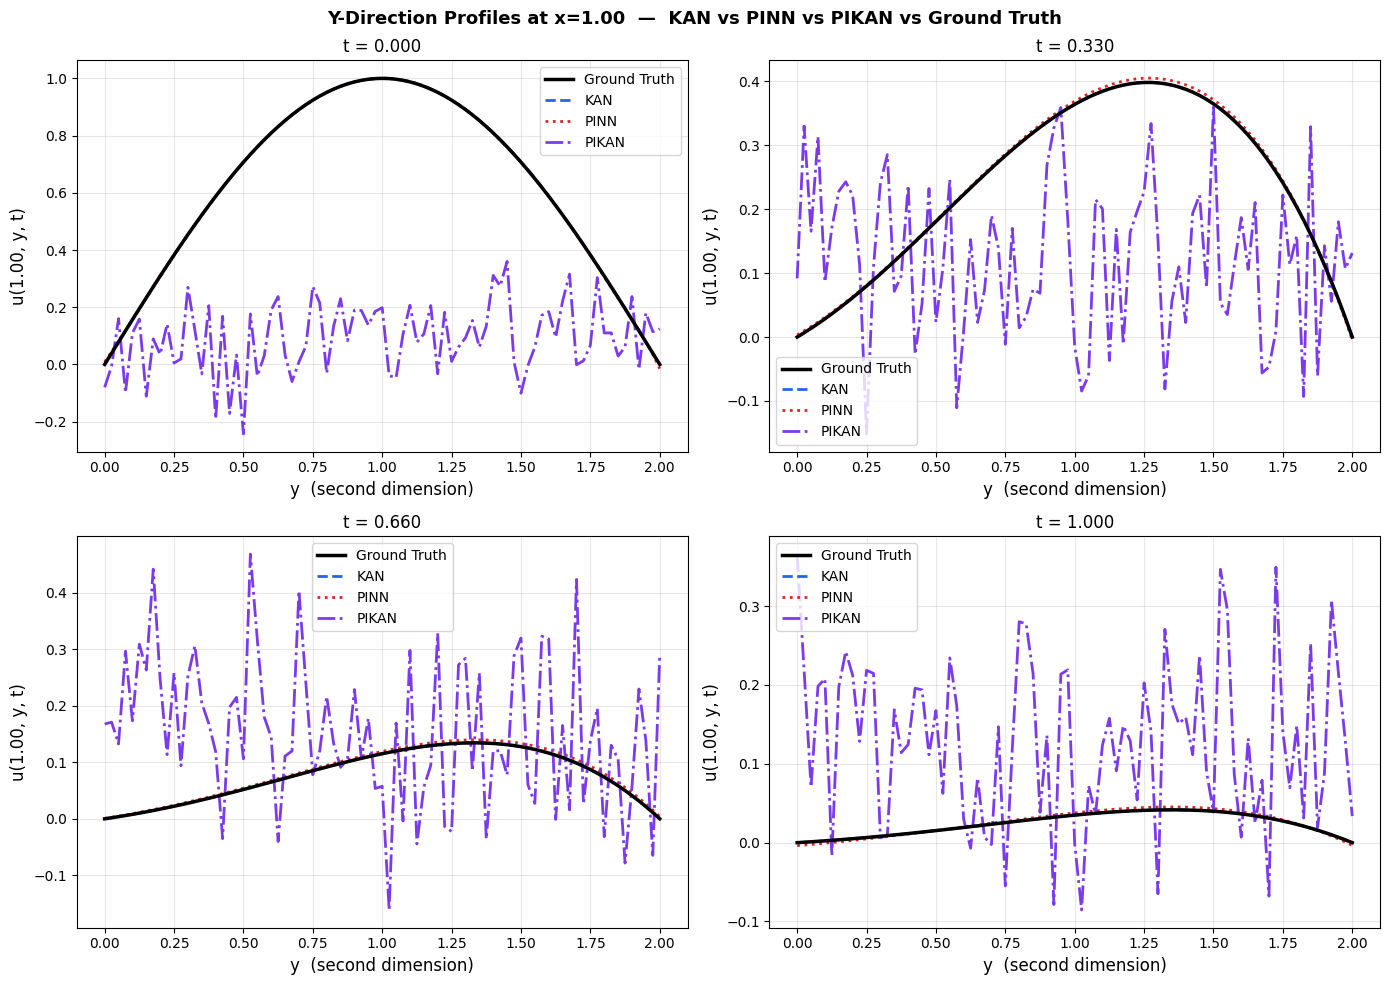

  -> saved COMPARE_04_y_profiles.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Y-Direction Profiles at x={x_grid[ix_mid]:.2f}  —  KAN vs PINN vs PIKAN vs Ground Truth',
    fontsize=13, fontweight='bold'
)

for ax, si in zip(axes.ravel(), snap_idxs_4):
    tk   = snap_t[si]
    gt_y = KAN_true_snaps[si,   ix_mid, :]
    kn_y = KAN_pred_snaps[si,   ix_mid, :]
    pn_y = PINN_pred_snaps[si,  ix_mid, :]
    pk_y = PIKAN_pred_snaps[si, ix_mid, :]
    ax.plot(y_grid, gt_y, 'k-',                    lw=2.5, label='Ground Truth', zorder=4)
    ax.plot(y_grid, kn_y, color='#2563EB', ls='--', lw=2.0, label='KAN')
    ax.plot(y_grid, pn_y, color='#DC2626', ls=':',  lw=2.0, label='PINN')
    ax.plot(y_grid, pk_y, color='#7C3AED', ls='-.',  lw=2.0, label='PIKAN')
    ax.set_title(f't = {tk:.3f}', fontsize=12)
    ax.set_xlabel('y  (second dimension)', fontsize=FS)
    ax.set_ylabel(f'u({x_grid[ix_mid]:.2f}, y, t)', fontsize=FS)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
save_and_show('COMPARE_04_y_profiles.png')

## 17. Final Summary

In [ ]:
print('\n' + '=' * 70)
print('  FINAL SUMMARY — KAN, PINN & PIKAN on 2D Advection-Diffusion PDE')
print('=' * 70)
print(f'  PDE       : du/dt + {CX}*du/dx + {CY}*du/dy = {D}*(d2u/dx2 + d2u/dy2)')
print(f'  IC        : u(x,y,0) = sin(2*pi/L^2 * x*y)')
print(f'  BC        : u = {BC_VAL} on all boundaries (Dirichlet)')
print(f'  Domain    : x,y in [0,{L}],  t in [0,{T}]')
print(f'  Grid      : Nx=Ny={Nx}, Dx=Dy={DX:.4f}, Dt={DT}')
print(f'  GT Solver : ADI-Crank-Nicolson (IMEX, upwind advection)')
print(f'  Inputs    : normalised to [-1, 1] for all models')
print()
print(f'  ── KAN ──────────────────────────────────────────────────────')
print(f'  Architecture  : {KAN_WIDTHS}  grid={KAN_GRID_SIZE}  order={KAN_SPLINE_ORD}')
print(f'  Parameters    : {kan_n_params:,}')
print(f'  Training      : Supervised regression on {len(snap_t)} GT snapshots')
print(f'  Optimiser     : AdamW + ReduceLROnPlateau')
print(f'  Stop reason   : {kan_stop_reason}')
print(f'  Epochs run    : {kan_final_epoch}')
print(f'  Best val MSE  : {kan_best_val:.6f}')
print(f'  Full MSE      : {kan_mse_full:.6f}')
print(f'  RMSE          : {kan_rmse_all:.6f}')
print(f'  Rel. L1 err   : {kan_rel_err*100:.2f} %')
print(f'  Training time : {kan_total_time:.1f}s ({kan_total_time/60:.1f} min)')
print()
print(f'  ── PINN ─────────────────────────────────────────────────────')
print(f'  Architecture  : MLP  width=128  depth=6')
print(f'  Parameters    : {pinn_n_params:,}')
print(f'  Training      : Physics-informed (PDE residual + IC + BC losses)')
print(f'  Loss weights  : w_f={PINN_W_F}, w_ic={PINN_W_IC}, w_bc={PINN_W_BC}')
print(f'  Optimiser     : Adam ({pinn_adam_epochs} epochs) + L-BFGS ({len(lbfgs_loss_hist)} steps)')
print(f'  Stop reason   : {pinn_stop_reason}')
print(f'  Adam epochs   : {pinn_adam_epochs}')
print(f'  L-BFGS steps  : {len(lbfgs_loss_hist)}')
print(f'  Best loss     : {pinn_best_loss:.6f}')
print(f'  Avg MSE (eval): {np.mean(pinn_mse_eval):.6f}')
print(f'  Training time : {pinn_total_time:.1f}s ({pinn_total_time/60:.1f} min)')
print()
print(f'  ── PIKAN ────────────────────────────────────────────────────')
print(f'  Architecture  : KAN[3,32,32,32,1]  grid=8  order=3')
print(f'  Parameters    : {pikan_n_params:,}')
print(f'  Training      : Dual-loss (supervised data + PDE residual + IC + BC)')
print(f'  Loss weights  : w_data={PIKAN_W_DATA}, w_pde={PIKAN_W_PDE}, w_ic={PIKAN_W_IC}, w_bc={PIKAN_W_BC}')
print(f'  Optimiser     : Adam ({pikan_final_epoch} epochs) + L-BFGS ({len(pikan_lbfgs_hist)} steps)')
print(f'  Stop reason   : {pikan_stop_reason}')
print(f'  Adam epochs   : {pikan_final_epoch}')
print(f'  L-BFGS steps  : {len(pikan_lbfgs_hist)}')
print(f'  Best loss     : {pikan_best_loss:.6f}')
print(f'  Avg MSE (eval): {np.mean(pikan_mse_eval):.6f}')
print(f'  Training time : {pikan_total_time:.1f}s ({pikan_total_time/60:.1f} min)')
print()
print(f'  All plots saved to: {OUT_DIR}/')
print('=' * 70)


  FINAL SUMMARY — KAN, PINN & PIKAN on 2D Advection-Diffusion PDE
  PDE       : du/dt + 1.0*du/dx + 1.0*du/dy = 0.5*(d2u/dx2 + d2u/dy2)
  IC        : u(x,y,0) = sin(2*pi/L^2 * x*y)
  BC        : u = 0.0 on all boundaries (Dirichlet)
  Domain    : x,y in [0,2.0],  t in [0,1.0]
  Grid      : Nx=Ny=80, Dx=Dy=0.0250, Dt=0.002
  GT Solver : ADI-Crank-Nicolson (IMEX, upwind advection)
  Inputs    : normalised to [-1, 1] for all models

  ── KAN ──────────────────────────────────────────────────────
  Architecture  : [3, 32, 32, 32, 1]  grid=8  order=3
  Parameters    : 26,304
  Training      : Supervised regression on 101 GT snapshots
  Optimiser     : AdamW + ReduceLROnPlateau
  Stop reason   : convergence
  Epochs run    : 156
  Best val MSE  : 0.000000
  Full MSE      : 0.000000
  RMSE          : 0.000149
  Rel. L1 err   : 0.07 %
  Training time : 2268.4s (37.8 min)

  ── PINN ─────────────────────────────────────────────────────
  Architecture  : MLP  width=128  depth=6
  Parameters    